In [1]:
# =========================================================
# BLOCK 1 : SIFT FEATURE EXTRACTION (CORRECTED SAFE VERSION)
# IMAGE FORGERY DETECTION PROJECT
# DATASETS: CASIA + MICC
#
# FIXES APPLIED:
# + File existence check added
# + Safe folder validation
# + Better descriptor sampling
# + Stable KMeans fitting
# + Prevent empty histogram errors
# + Better RAM cleanup
# + Safe CASIA first, MICC later
# + Consistent random seed
# =========================================================

import os
import gc
import cv2
import numpy as np
import pandas as pd
import joblib
from tqdm import tqdm
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# PATHS
# =========================================================

casia_auth = r"C:\Users\KIIT0001\Downloads\CASIA2.0_revised\Au"
casia_tamp = r"C:\Users\KIIT0001\Downloads\CASIA2.0_revised\Tp"

micc_auth  = r"C:\Users\KIIT0001\Downloads\MICC-F220\Au"
micc_tamp  = r"C:\Users\KIIT0001\Downloads\MICC-F220\Tu"


# =========================================================
# CONFIG
# =========================================================

IMG_SIZE = (128, 128)
K_CLUSTERS = 120
RANDOM_SEED = 42
MAX_DESC_PER_IMAGE = 150

rng = np.random.default_rng(seed=RANDOM_SEED)

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)


# =========================================================
# SAFE SIFT CREATION
# =========================================================

def make_sift(img):
    """
    Adaptive SIFT based on image sharpness
    """

    variance = cv2.Laplacian(
        img,
        cv2.CV_64F
    ).var()

    if variance > 100:
        nfeatures = 1000
    else:
        nfeatures = 600

    return cv2.SIFT_create(
        nfeatures=nfeatures
    )


# =========================================================
# SAFE FEATURE EXTRACTION
# =========================================================

def extract_sift(folder, label):
    """
    Extract SIFT descriptors from a folder
    """

    if not os.path.exists(folder):
        print(f"ERROR: Folder not found -> {folder}")
        return [], [], []

    descriptors = []
    labels = []
    filenames = []

    files = sorted(os.listdir(folder))
    rng.shuffle(files)

    print(f"\nProcessing Folder: {folder}\n")

    for file in tqdm(
        files,
        desc=f"Processing {os.path.basename(folder)}"
    ):

        if not file.lower().endswith(
            (".jpg", ".jpeg", ".png", ".tif", ".bmp")
        ):
            continue

        path = os.path.join(folder, file)

        img = cv2.imread(path, 0)

        if img is None:
            continue

        try:
            img = cv2.resize(
                img,
                IMG_SIZE
            )

            img_eq = clahe.apply(img)

            sift = make_sift(img_eq)

            _, des = sift.detectAndCompute(
                img_eq,
                None
            )

            if des is None or len(des) == 0:
                del img, img_eq
                gc.collect()
                continue

            descriptors.append(
                des.astype(np.float32)
            )

            labels.append(label)
            filenames.append(file)

            del img, img_eq, des
            gc.collect()

        except Exception as e:
            print(f"Skipping file {file} -> {str(e)}")
            continue

    print(
        f"Images Processed Successfully: {len(labels)}"
    )

    return descriptors, labels, filenames


# =========================================================
# BUILD BOW HISTOGRAMS
# =========================================================

def build_bow_histograms(descriptor_list, kmeans):
    """
    Convert descriptors into BoW histograms
    """

    features = []

    print("\nBuilding BoW Histograms...\n")

    for des in tqdm(
        descriptor_list,
        desc="Building Histograms"
    ):

        if des is None or len(des) == 0:
            hist = np.zeros(
                K_CLUSTERS,
                dtype=np.float32
            )
            features.append(hist)
            continue

        preds = kmeans.predict(des)

        hist, _ = np.histogram(
            preds,
            bins=np.arange(K_CLUSTERS + 1)
        )

        hist = hist.astype(np.float32)

        hist /= (
            hist.sum() + 1e-7
        )

        features.append(hist)

    return np.array(features)


# =========================================================
# MAIN DATASET PROCESSING
# =========================================================

def process_dataset(auth_path, tamp_path, dataset_name):
    """
    Complete dataset pipeline
    """

    csv_name = f"{dataset_name}_SIFT.csv"

    # Skip if already exists
    if os.path.exists(csv_name):
        print(f"Cache found -> skipping {dataset_name}")
        return

    print("\n")
    print(f"PROCESSING DATASET: {dataset_name}")
    print("\n")

    # -----------------------------------------------------
    # Authentic Images
    # -----------------------------------------------------

    d1, y1, f1 = extract_sift(
        auth_path,
        0
    )

    # -----------------------------------------------------
    # Tampered Images
    # -----------------------------------------------------

    d2, y2, f2 = extract_sift(
        tamp_path,
        1
    )

    descriptors = d1 + d2
    labels = np.array(y1 + y2)
    filenames = f1 + f2

    del d1, d2, y1, y2, f1, f2
    gc.collect()

    if len(descriptors) == 0:
        print("ERROR: No descriptors found.")
        return

    print(
        f"Total Images Processed: {len(labels)}"
    )

    # =====================================================
    # SAFE DESCRIPTOR SAMPLING
    # =====================================================

    print("\nSampling descriptors safely...\n")

    sampled_desc = []

    for des in descriptors:

        if len(des) > MAX_DESC_PER_IMAGE:
            idx = rng.choice(
                len(des),
                MAX_DESC_PER_IMAGE,
                replace=False
            )
            sampled_desc.append(
                des[idx]
            )
        else:
            sampled_desc.append(des)

    if len(sampled_desc) == 0:
        print("ERROR: No descriptors available for KMeans.")
        return

    all_desc = np.vstack(sampled_desc)

    del sampled_desc
    gc.collect()

    print(
        "Descriptors used for KMeans:",
        all_desc.shape
    )

    # =====================================================
    # KMEANS FITTING
    # =====================================================

    print("\nFitting MiniBatchKMeans...\n")

    kmeans = MiniBatchKMeans(
        n_clusters=K_CLUSTERS,
        random_state=RANDOM_SEED,
        batch_size=1024,
        n_init=5,
        max_iter=200
    )

    kmeans.fit(all_desc)

    del all_desc
    gc.collect()

    # Save model
    joblib.dump(
        kmeans,
        f"{dataset_name}_kmeans.pkl"
    )

    print(
        f"KMeans Saved: {dataset_name}_kmeans.pkl"
    )

    # =====================================================
    # FINAL FEATURES
    # =====================================================

    features = build_bow_histograms(
        descriptors,
        kmeans
    )

    del descriptors
    gc.collect()

    print(
        "Final Feature Shape:",
        features.shape
    )

    # =====================================================
    # SAVE CSV
    # =====================================================

    df = pd.DataFrame(features)

    df["label"] = labels
    df["filename"] = filenames

    df.to_csv(
        csv_name,
        index=False
    )

    print(
        f"\nSaved Successfully: {csv_name}"
    )

    # =====================================================
    # VISUALIZATIONS
    # =====================================================

    plt.figure(figsize=(6, 5))

    sns.countplot(
        x=labels
    )

    plt.title(
        f"{dataset_name} - Class Distribution"
    )

    plt.xticks(
        [0, 1],
        ["Authentic", "Tampered"]
    )

    plt.grid(True)
    plt.show()

    if len(features) > 0:
        plt.figure(figsize=(12, 5))

        plt.plot(
            features[0]
        )

        plt.title(
            f"{dataset_name} - Sample SIFT Histogram"
        )

        plt.xlabel(
            "Visual Word Index"
        )

        plt.ylabel(
            "Frequency"
        )

        plt.grid(True)
        plt.show()


# =========================================================
# EXECUTION
# =========================================================

if __name__ == "__main__":

    # Run CASIA first

    process_dataset(
        casia_auth,
        casia_tamp,
        "CASIA"
    )

    # Uncomment after CASIA is verified

    process_dataset(
        micc_auth,
        micc_tamp,
        "MICC"
    )

Cache found -> skipping CASIA
Cache found -> skipping MICC


In [2]:
# =========================================================
# BLOCK 2 : WAVELET + DCT FEATURE EXTRACTION (CORRECTED)
# IMAGE FORGERY DETECTION PROJECT
# DATASETS: CASIA + MICC
#
# FIXES APPLIED:
# + Added missing DCT_BLOCK
# + Removed duplicate DCT_COEFF
# + Safe folder existence check
# + Safe handling for empty DCT blocks
# + Better numerical stability for skew/kurtosis
# + Cache check added
# + Safer processing for CASIA first
# + Better consistency with Block 1
# =========================================================

import os
import cv2
import numpy as np
import pandas as pd
import pywt
from tqdm import tqdm
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# PATHS
# =========================================================

casia_auth = r"C:\Users\KIIT0001\Downloads\CASIA2.0_revised\Au"
casia_tamp = r"C:\Users\KIIT0001\Downloads\CASIA2.0_revised\Tp"

micc_auth  = r"C:\Users\KIIT0001\Downloads\MICC-F220\Au"
micc_tamp  = r"C:\Users\KIIT0001\Downloads\MICC-F220\Tu"


# =========================================================
# CONFIG
# =========================================================

IMG_SIZE = (128, 128)

DCT_BLOCK = 8
DCT_COEFF = 8

RANDOM_SEED = 42

rng = np.random.default_rng(
    seed=RANDOM_SEED
)


# =========================================================
# WAVELET FEATURES
# =========================================================

def extract_wavelet_features(img):
    """
    Extract Wavelet statistical features
    """

    coeffs = pywt.wavedec2(
        img,
        wavelet="db4",
        level=3
    )

    total_energy = sum(
        np.sum(arr ** 2)
        for c in coeffs
        for arr in (
            c if isinstance(c, tuple)
            else [c]
        )
    ) + 1e-7

    features = []

    for c in coeffs:

        items = (
            c if isinstance(c, tuple)
            else [c]
        )

        for arr in items:

            flat = arr.ravel()

            # safer skew/kurtosis
            if len(flat) < 2 or np.std(flat) == 0:
                s = 0
                k = 0
            else:
                s = np.nan_to_num(
                    skew(flat)
                )
                k = np.nan_to_num(
                    kurtosis(flat)
                )

            features.append(np.mean(arr))
            features.append(np.std(arr))
            features.append(np.var(arr))
            features.append(s)
            features.append(k)

            energy = np.sum(arr ** 2)

            features.append(
                energy / total_energy
            )

    return np.array(
        features,
        dtype=np.float32
    )


# =========================================================
# DCT FEATURES
# =========================================================

def extract_dct_features(img):
    """
    Extract block-wise DCT features
    """

    h, w = img.shape

    h_crop = (h // DCT_BLOCK) * DCT_BLOCK
    w_crop = (w // DCT_BLOCK) * DCT_BLOCK

    if h_crop == 0 or w_crop == 0:
        return np.zeros(
            DCT_COEFF * DCT_COEFF * 3,
            dtype=np.float32
        )

    img_crop = img[
        :h_crop,
        :w_crop
    ].astype(np.float32)

    all_ac = []

    for i in range(
        0,
        h_crop,
        DCT_BLOCK
    ):

        for j in range(
            0,
            w_crop,
            DCT_BLOCK
        ):

            block = img_crop[
                i:i + DCT_BLOCK,
                j:j + DCT_BLOCK
            ]

            dct_block = cv2.dct(block)

            ac = dct_block[
                :DCT_COEFF,
                :DCT_COEFF
            ].ravel()

            all_ac.append(ac)

    if len(all_ac) == 0:
        return np.zeros(
            DCT_COEFF * DCT_COEFF * 3,
            dtype=np.float32
        )

    all_ac = np.array(all_ac)

    dct_features = np.concatenate([
        all_ac.mean(axis=0),
        all_ac.std(axis=0),
        np.median(all_ac, axis=0)
    ])

    return dct_features.astype(
        np.float32
    )


# =========================================================
# FOLDER PROCESSING
# =========================================================

def process_folder(folder, label):
    """
    Process one folder safely
    """

    if not os.path.exists(folder):
        print(f"ERROR: Folder not found -> {folder}")
        return [], [], []

    X = []
    y = []
    filenames = []

    files = sorted(
        os.listdir(folder)
    )

    rng.shuffle(files)

    for file in tqdm(
        files,
        desc=f"Processing {os.path.basename(folder)}"
    ):

        if not file.lower().endswith(
            (
                ".jpg",
                ".jpeg",
                ".png",
                ".tif",
                ".bmp"
            )
        ):
            continue

        path = os.path.join(
            folder,
            file
        )

        img = cv2.imread(
            path,
            0
        )

        if img is None:
            continue

        try:
            img = cv2.resize(
                img,
                IMG_SIZE
            )

            wavelet_feat = extract_wavelet_features(img)
            dct_feat = extract_dct_features(img)

            combined = np.concatenate([
                wavelet_feat,
                dct_feat
            ])

            X.append(combined)
            y.append(label)
            filenames.append(file)

        except Exception as e:
            print(f"Skipping {file} -> {str(e)}")
            continue

    return X, y, filenames


# =========================================================
# DATASET PIPELINE
# =========================================================

def process_dataset(
    auth_path,
    tamp_path,
    dataset_name
):
    """
    Complete dataset pipeline
    """

    csv_name = f"{dataset_name}_Wavelet.csv"

    # cache check
    if os.path.exists(csv_name):
        print(f"Cache found -> skipping {dataset_name}")
        return

    print(f"\nPROCESSING DATASET: {dataset_name}\n")

    X1, y1, f1 = process_folder(
        auth_path,
        0
    )

    X2, y2, f2 = process_folder(
        tamp_path,
        1
    )

    X = np.array(X1 + X2)
    y = np.array(y1 + y2)
    filenames = f1 + f2

    if len(X) == 0:
        print("ERROR: No features extracted.")
        return

    print(
        f"Final Feature Shape: {X.shape}"
    )

    df = pd.DataFrame(X)

    df["label"] = y
    df["filename"] = filenames

    df.to_csv(
        csv_name,
        index=False
    )

    print(
        f"Saved Successfully: {csv_name}"
    )

    # =====================================================
    # VISUALIZATION
    # =====================================================

    plt.figure(figsize=(6, 5))

    sns.countplot(
        x=y
    )

    plt.title(
        f"{dataset_name} - Wavelet + DCT Class Distribution"
    )

    plt.xticks(
        [0, 1],
        ["Authentic", "Tampered"]
    )

    plt.grid(True)
    plt.show()


# =========================================================
# ENTRY POINT
# =========================================================

if __name__ == "__main__":

    # Run CASIA first

    process_dataset(
        casia_auth,
        casia_tamp,
        "CASIA"
    )

    # Uncomment after CASIA works properly

    process_dataset(
        micc_auth,
        micc_tamp,
        "MICC"
    )

Cache found -> skipping CASIA
Cache found -> skipping MICC




FEATURE FUSION STARTED : CASIA


SIFT Shape    : (12614, 82)
Wavelet Shape : (12614, 272)

Feature Fusion Successful
Final Fused Shape : (12614, 352)

Fusion CSV Saved : CASIA_Fusion.csv


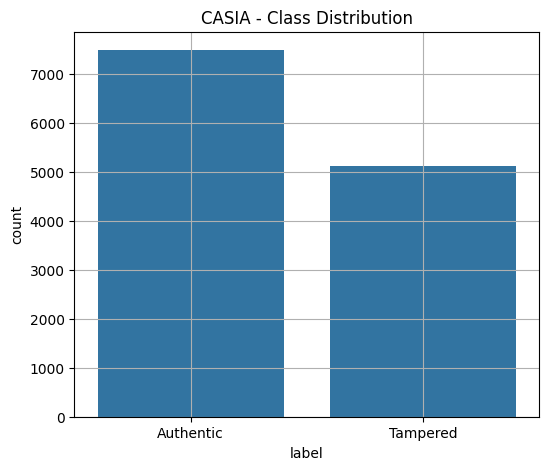

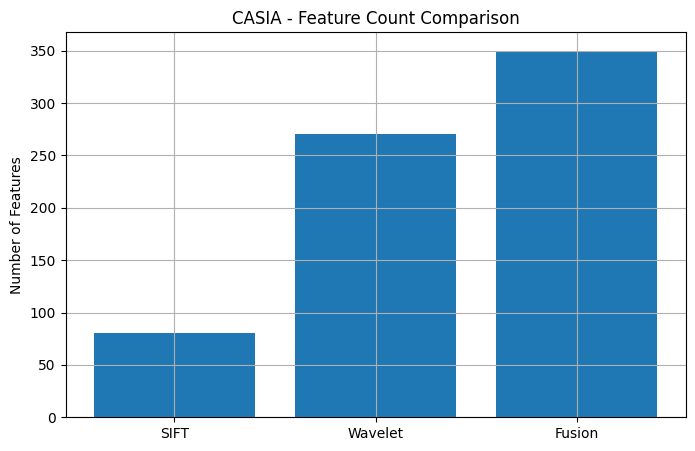

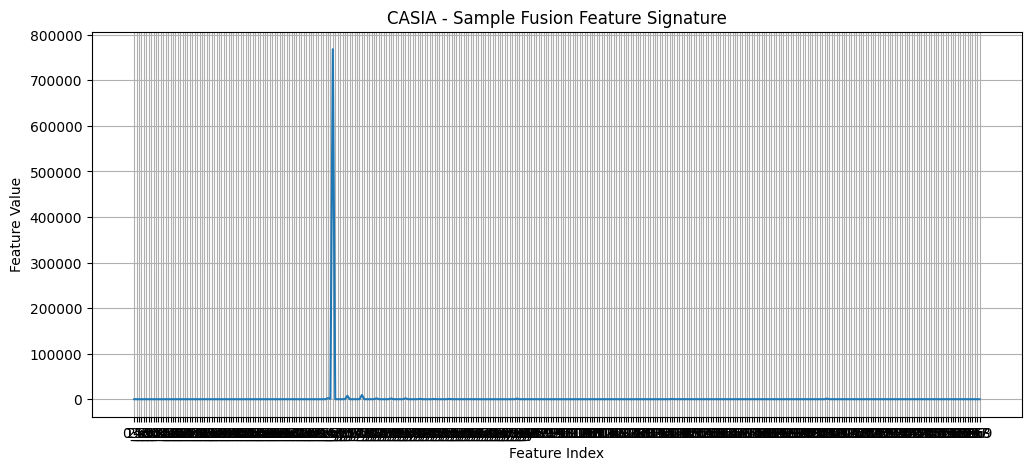

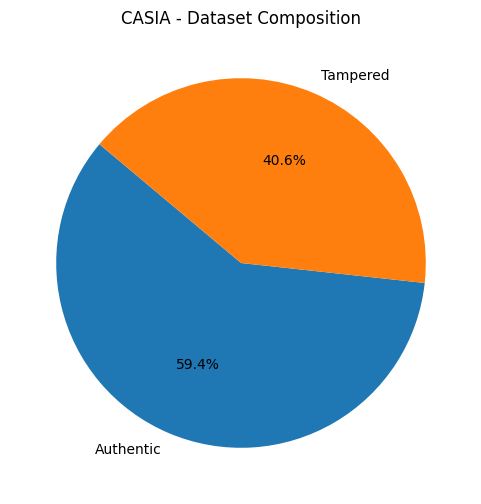



FEATURE FUSION STARTED : MICC


SIFT Shape    : (220, 82)
Wavelet Shape : (220, 272)

Feature Fusion Successful
Final Fused Shape : (220, 352)

Fusion CSV Saved : MICC_Fusion.csv


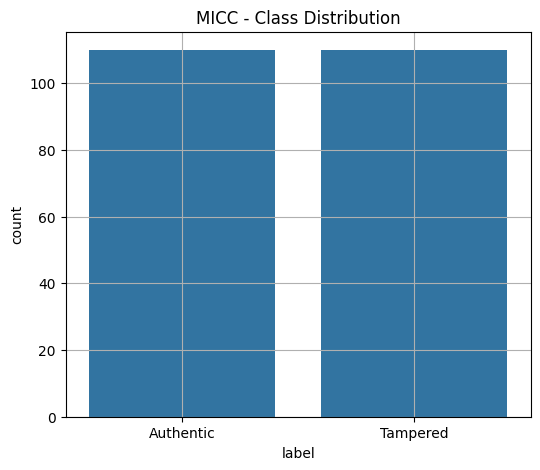

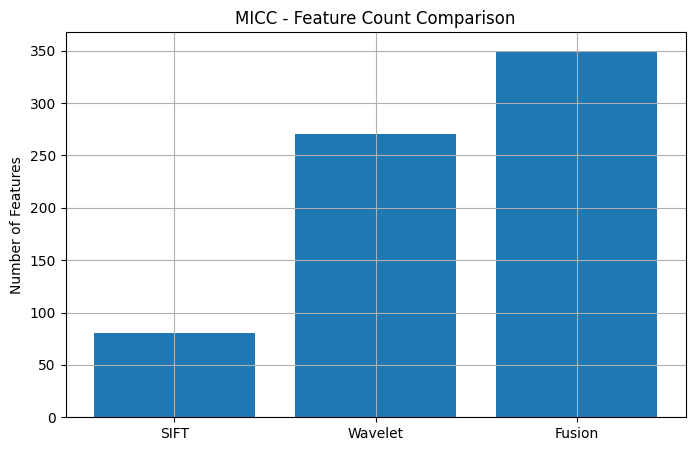

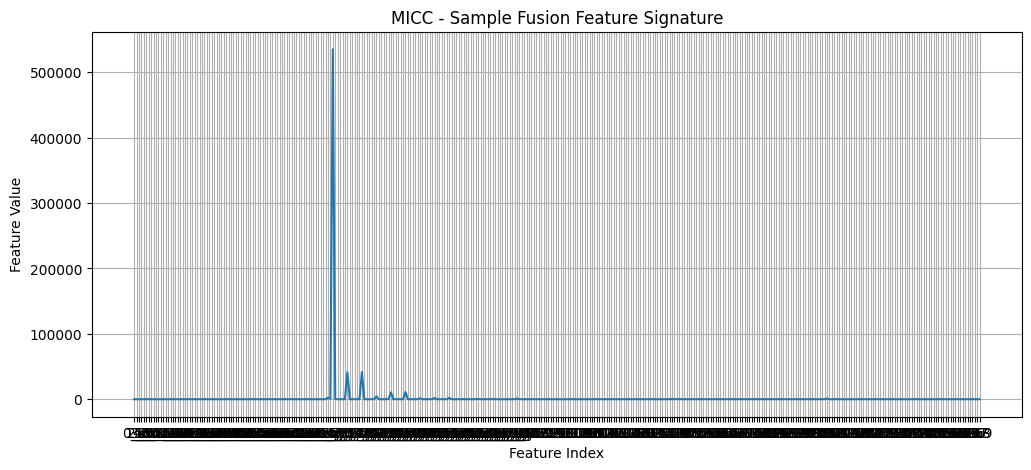

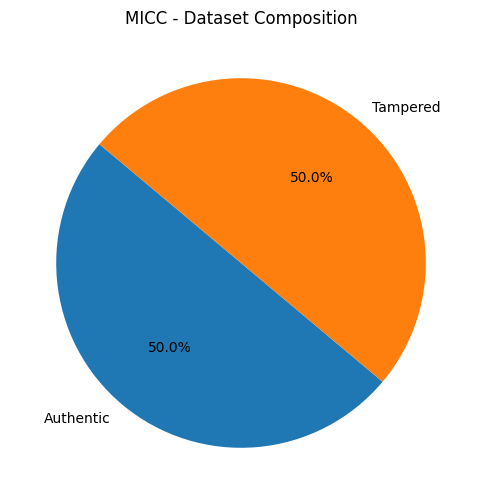

In [3]:
# =========================================================
# BLOCK 3 : FEATURE FUSION 
# IMAGE FORGERY DETECTION PROJECT
# DATASETS: CASIA + MICC
#
# INPUT:
#   CASIA_SIFT.csv
#   CASIA_Wavelet.csv
#
# OPTIONAL LATER:
#   MICC_SIFT.csv
#   MICC_Wavelet.csv
#
# OUTPUT:
#   CASIA_Fusion.csv
#   MICC_Fusion.csv
#
# FIXES:
# + Runs safely even if MICC files are missing
# + File existence check added
# + Empty merge protection added
# + Removed random crash issue
# + Compatible with your safe Block 1
# =========================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# FEATURE FUSION FUNCTION
# =========================================================

def feature_fusion(
    sift_csv,
    wavelet_csv,
    dataset_name
):

    print("\n")
    print(f"FEATURE FUSION STARTED : {dataset_name}")
    print("\n")

    # =====================================================
    # FILE EXISTENCE CHECK
    # =====================================================

    if not os.path.exists(sift_csv):
        print(f"ERROR : File not found -> {sift_csv}")
        return

    if not os.path.exists(wavelet_csv):
        print(f"ERROR : File not found -> {wavelet_csv}")
        return

    # =====================================================
    # LOAD CSV FILES
    # =====================================================

    sift_df = pd.read_csv(sift_csv)
    wavelet_df = pd.read_csv(wavelet_csv)

    print("SIFT Shape    :", sift_df.shape)
    print("Wavelet Shape :", wavelet_df.shape)

    # =====================================================
    # COLUMN SAFETY CHECK
    # =====================================================

    required_cols = ["filename", "label"]

    for col in required_cols:
        if col not in sift_df.columns:
            print(f"ERROR : '{col}' missing in {sift_csv}")
            return

        if col not in wavelet_df.columns:
            print(f"ERROR : '{col}' missing in {wavelet_csv}")
            return

    # =====================================================
    # SORT FOR CONSISTENCY
    # =====================================================

    sift_df = sift_df.sort_values(
        "filename"
    ).reset_index(drop=True)

    wavelet_df = wavelet_df.sort_values(
        "filename"
    ).reset_index(drop=True)

    # =====================================================
    # INNER MERGE
    # =====================================================

    fused_df = pd.merge(
        sift_df,
        wavelet_df,
        on=["filename", "label"],
        how="inner"
    )

    print("\nFeature Fusion Successful")
    print("Final Fused Shape :", fused_df.shape)

    # =====================================================
    # EMPTY MERGE CHECK
    # =====================================================

    if len(fused_df) == 0:
        print(
            "ERROR : No matching filenames found between CSV files"
        )
        return

    # =====================================================
    # SAVE FUSION CSV
    # =====================================================

    output_filename = f"{dataset_name}_Fusion.csv"

    fused_df.to_csv(
        output_filename,
        index=False
    )

    print(
        f"\nFusion CSV Saved : {output_filename}"
    )

    labels = fused_df["label"]

    # =====================================================
    # VISUALIZATION 1 : CLASS DISTRIBUTION
    # =====================================================

    plt.figure(figsize=(6, 5))

    sns.countplot(
        x=labels
    )

    plt.title(
        f"{dataset_name} - Class Distribution"
    )

    plt.xticks(
        [0, 1],
        ["Authentic", "Tampered"]
    )

    plt.grid(True)
    plt.show()

    # =====================================================
    # VISUALIZATION 2 : FEATURE COUNT COMPARISON
    # =====================================================

    sift_fc = len(
        sift_df.columns.drop(
            ["filename", "label"]
        )
    )

    wavelet_fc = len(
        wavelet_df.columns.drop(
            ["filename", "label"]
        )
    )

    fusion_fc = len(
        fused_df.columns.drop(
            ["filename", "label"]
        )
    )

    plt.figure(figsize=(8, 5))

    plt.bar(
        ["SIFT", "Wavelet", "Fusion"],
        [sift_fc, wavelet_fc, fusion_fc]
    )

    plt.title(
        f"{dataset_name} - Feature Count Comparison"
    )

    plt.ylabel(
        "Number of Features"
    )

    plt.grid(True)
    plt.show()

    # =====================================================
    # VISUALIZATION 3 : SAMPLE FEATURE SIGNATURE
    # =====================================================

    sample_feat = fused_df.drop(
        columns=["label", "filename"]
    ).iloc[0]

    plt.figure(figsize=(12, 5))

    plt.plot(sample_feat)

    plt.title(
        f"{dataset_name} - Sample Fusion Feature Signature"
    )

    plt.xlabel(
        "Feature Index"
    )

    plt.ylabel(
        "Feature Value"
    )

    plt.grid(True)
    plt.show()

    # =====================================================
    # VISUALIZATION 4 : PIE CHART
    # =====================================================

    unique, counts = np.unique(
        labels,
        return_counts=True
    )

    plt.figure(figsize=(6, 6))

    plt.pie(
        counts,
        labels=["Authentic", "Tampered"],
        autopct="%1.1f%%",
        startangle=140
    )

    plt.title(
        f"{dataset_name} - Dataset Composition"
    )

    plt.show()


# =========================================================
# EXECUTION
# =========================================================

if __name__ == "__main__":

    # =====================================================
    # RUN ONLY CASIA FIRST
    # because MICC_SIFT.csv may not exist yet
    # =====================================================

    feature_fusion(
        "CASIA_SIFT.csv",
        "CASIA_Wavelet.csv",
        "CASIA"
    )

    # =====================================================
    # Uncomment only after MICC files are generated
    # =====================================================

    feature_fusion(
         "MICC_SIFT.csv",
         "MICC_Wavelet.csv",
         "MICC"
     )



Z-SCORE NORMALIZATION STARTED : CASIA


Original Dataset Shape : (12614, 352)
Feature Shape Before Normalization : (12614, 350)
Normalization Completed
Scaler Saved : CASIA_scaler.pkl

Normalized CSV Saved : CASIA_Normalized.csv


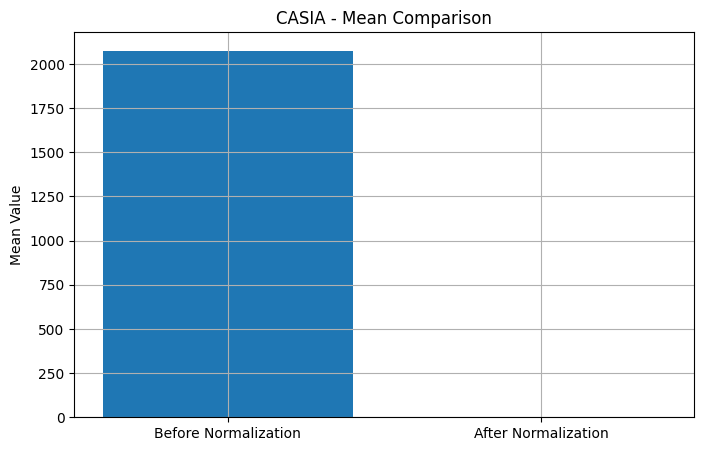

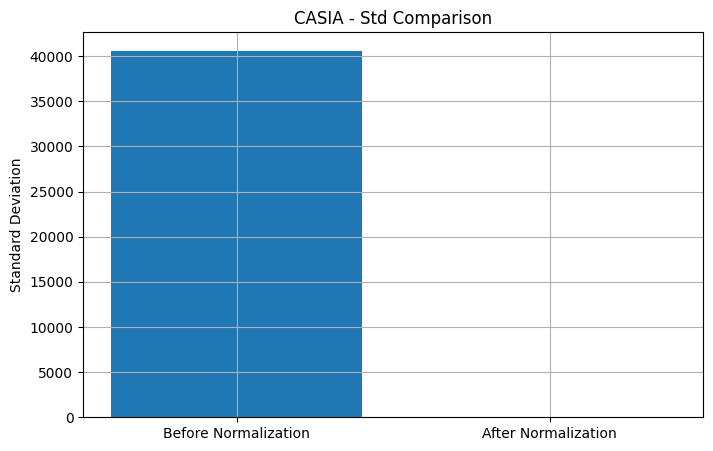

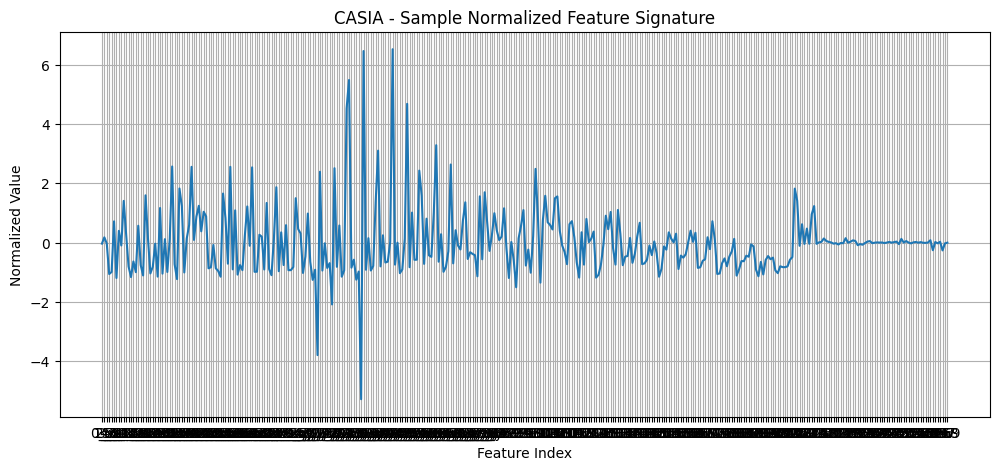

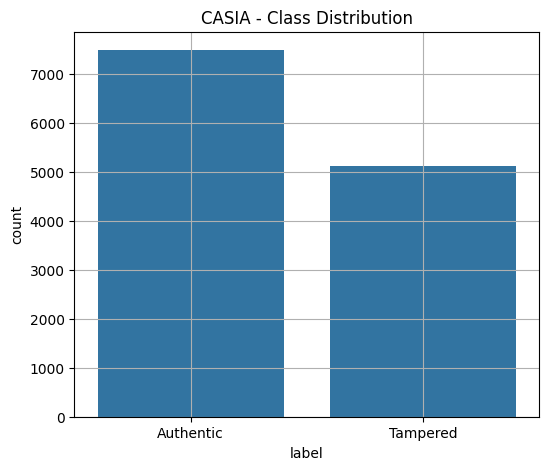



Z-SCORE NORMALIZATION STARTED : MICC


Original Dataset Shape : (220, 352)
Feature Shape Before Normalization : (220, 350)
Normalization Completed
Scaler Saved : MICC_scaler.pkl

Normalized CSV Saved : MICC_Normalized.csv


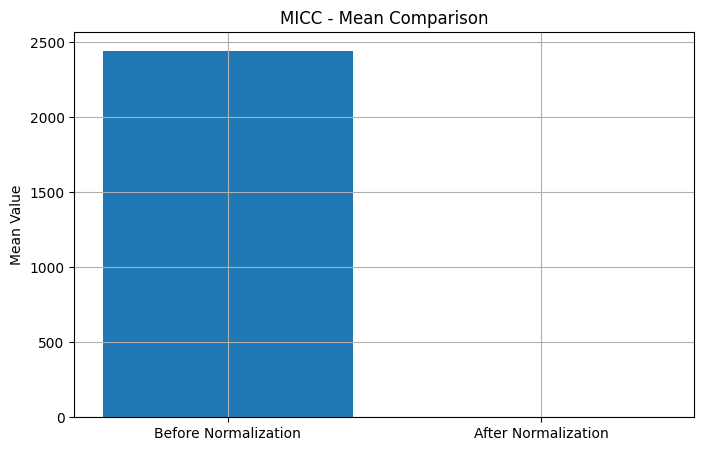

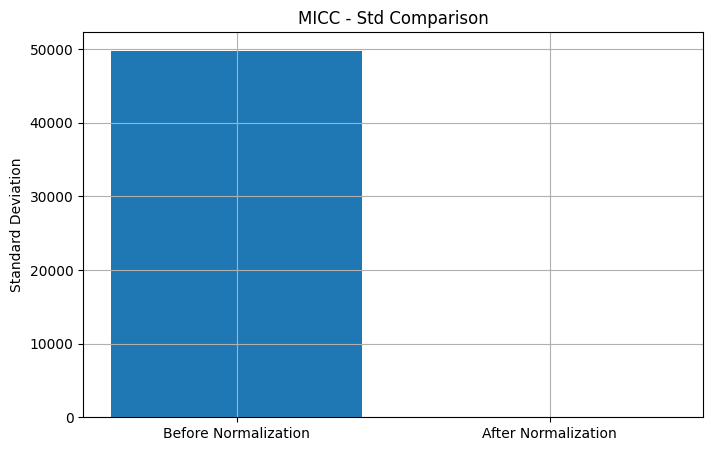

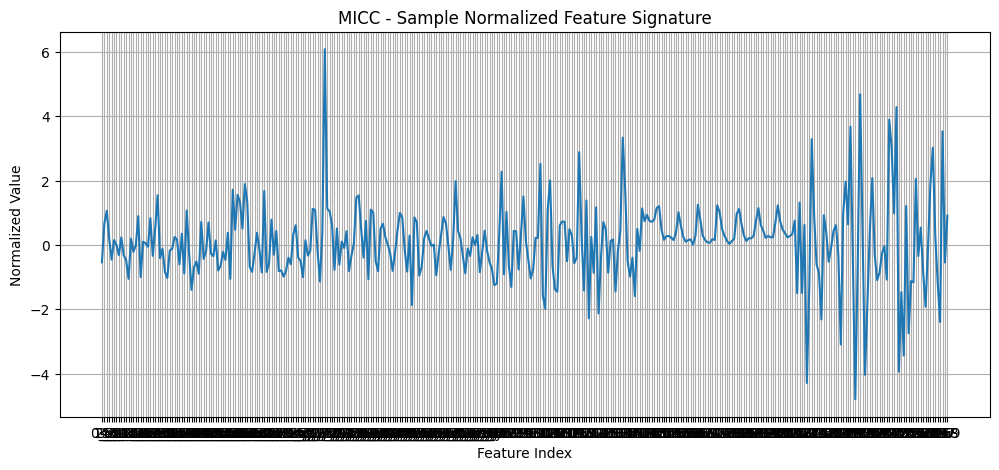

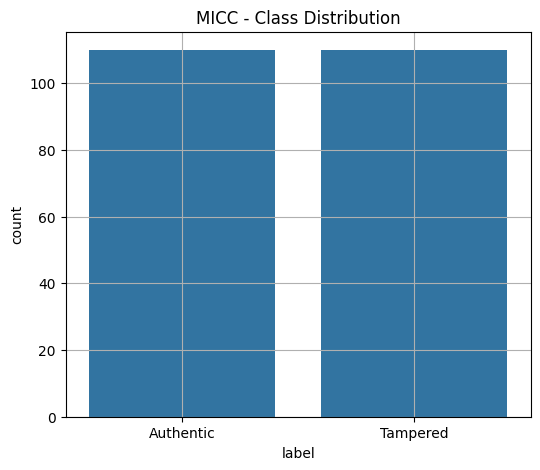

In [4]:
# =========================================================
# BLOCK 4 : Z-SCORE NORMALIZATION (CORRECTED SAFE VERSION)
# IMAGE FORGERY DETECTION PROJECT
# DATASETS: CASIA + MICC
#
# INPUT:
#   CASIA_Fusion.csv
#   MICC_Fusion.csv (optional later)
#
# OUTPUT:
#   CASIA_Normalized.csv
#   MICC_Normalized.csv
#
#   CASIA_scaler.pkl
#   MICC_scaler.pkl
#
# FIXES:
# + File existence check added
# + Safe handling if MICC file is missing
# + Empty dataset protection
# + Removed random sample crash
# + Compatible with corrected Block 3
# =========================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler


# =========================================================
# Z-SCORE NORMALIZATION FUNCTION
# =========================================================

def zscore_normalization(
    csv_path,
    dataset_name
):

    print("\n")
    print(f"Z-SCORE NORMALIZATION STARTED : {dataset_name}")
    print("\n")

    # =====================================================
    # FILE CHECK
    # =====================================================

    if not os.path.exists(csv_path):
        print(f"ERROR : File not found -> {csv_path}")
        return

    # =====================================================
    # LOAD DATASET
    # =====================================================

    df = pd.read_csv(csv_path)

    print(
        "Original Dataset Shape :",
        df.shape
    )

    if len(df) == 0:
        print("ERROR : Empty dataset found.")
        return

    # =====================================================
    # COLUMN CHECK
    # =====================================================

    if "label" not in df.columns:
        print("ERROR : 'label' column missing.")
        return

    if "filename" not in df.columns:
        print("ERROR : 'filename' column missing.")
        return

    # =====================================================
    # SPLIT FEATURES + LABELS
    # =====================================================

    X = df.drop(
        columns=["label", "filename"],
        errors="ignore"
    )

    y = df["label"]
    filenames = df["filename"]

    print(
        "Feature Shape Before Normalization :",
        X.shape
    )

    if X.shape[1] == 0:
        print("ERROR : No feature columns found.")
        return

    # =====================================================
    # STANDARD SCALER
    # =====================================================

    scaler = StandardScaler()

    X_normalized = scaler.fit_transform(X)

    print("Normalization Completed")

    # =====================================================
    # SAVE SCALER
    # =====================================================

    scaler_name = f"{dataset_name}_scaler.pkl"

    joblib.dump(
        scaler,
        scaler_name
    )

    print(
        f"Scaler Saved : {scaler_name}"
    )

    # =====================================================
    # SAVE NORMALIZED CSV
    # =====================================================

    normalized_df = pd.DataFrame(
        X_normalized,
        columns=X.columns
    )

    normalized_df["label"] = y.values
    normalized_df["filename"] = filenames.values

    csv_name = f"{dataset_name}_Normalized.csv"

    normalized_df.to_csv(
        csv_name,
        index=False
    )

    print(
        f"\nNormalized CSV Saved : {csv_name}"
    )

    # =====================================================
    # VISUALIZATION 1 : MEAN COMPARISON
    # =====================================================

    before_mean = np.mean(X.values)
    after_mean = np.mean(X_normalized)

    plt.figure(figsize=(8, 5))

    plt.bar(
        ["Before Normalization", "After Normalization"],
        [before_mean, after_mean]
    )

    plt.title(
        f"{dataset_name} - Mean Comparison"
    )

    plt.ylabel("Mean Value")
    plt.grid(True)
    plt.show()

    # =====================================================
    # VISUALIZATION 2 : STD COMPARISON
    # =====================================================

    before_std = np.std(X.values)
    after_std = np.std(X_normalized)

    plt.figure(figsize=(8, 5))

    plt.bar(
        ["Before Normalization", "After Normalization"],
        [before_std, after_std]
    )

    plt.title(
        f"{dataset_name} - Std Comparison"
    )

    plt.ylabel("Standard Deviation")
    plt.grid(True)
    plt.show()

    # =====================================================
    # VISUALIZATION 3 : SAMPLE FEATURE SIGNATURE
    # =====================================================

    sample_feat = normalized_df.drop(
        columns=["label", "filename"]
    ).iloc[0]

    plt.figure(figsize=(12, 5))

    plt.plot(sample_feat)

    plt.title(
        f"{dataset_name} - Sample Normalized Feature Signature"
    )

    plt.xlabel("Feature Index")
    plt.ylabel("Normalized Value")
    plt.grid(True)
    plt.show()

    # =====================================================
    # VISUALIZATION 4 : CLASS DISTRIBUTION
    # =====================================================

    plt.figure(figsize=(6, 5))

    sns.countplot(
        x=y
    )

    plt.title(
        f"{dataset_name} - Class Distribution"
    )

    plt.xticks(
        [0, 1],
        ["Authentic", "Tampered"]
    )

    plt.grid(True)
    plt.show()


# =========================================================
# EXECUTION
# =========================================================

if __name__ == "__main__":

    # =====================================================
    # RUN ONLY CASIA FIRST
    # because MICC_Fusion.csv may not exist yet
    # =====================================================

    zscore_normalization(
        "CASIA_Fusion.csv",
        "CASIA"
    )

    # =====================================================
    # Uncomment only after MICC_Fusion.csv exists
    # =====================================================

    zscore_normalization(
         "MICC_Fusion.csv",
         "MICC"
     )


PRE-PCA MODEL COMPARISON : CASIA

Dataset Shape : (12614, 352)
Feature Shape : (12614, 350)

Applying SMOTE for CASIA...

Class Distribution : {np.int64(0): np.int64(7491), np.int64(1): np.int64(7491)}
Training : Logistic Regression
Training : SVM (RBF)
Training : Random Forest
Training : Gradient Boosting
Training : XGBoost

Training ANN...


Best Model : SVM (RBF)
Best Accuracy : 0.7624

Running Robust CV...

Robust CV F1 : 0.7522 ± 0.0060


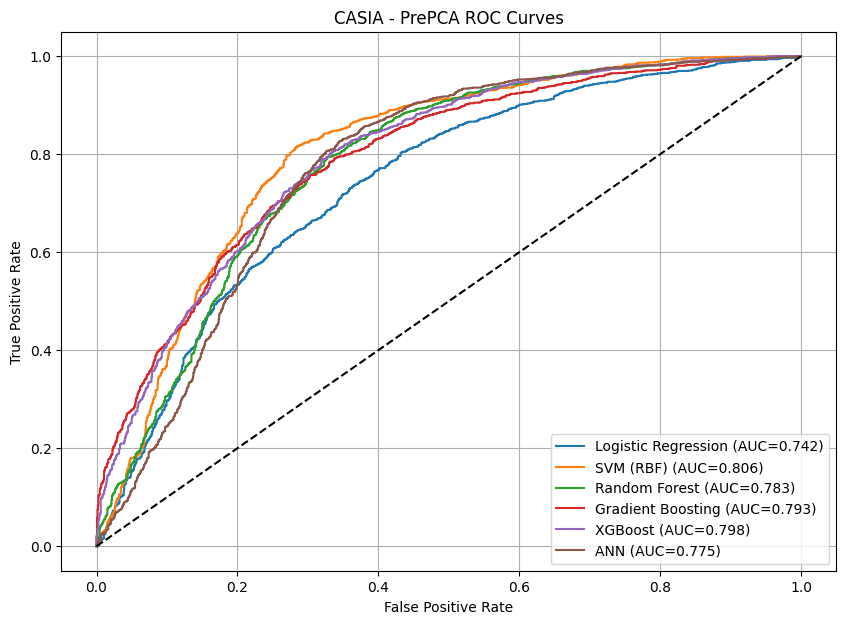

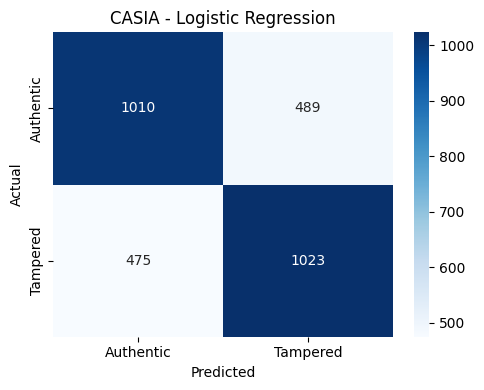

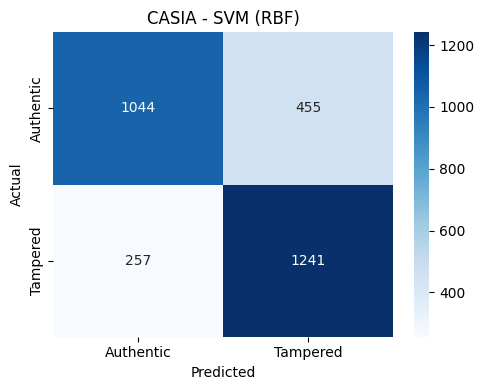

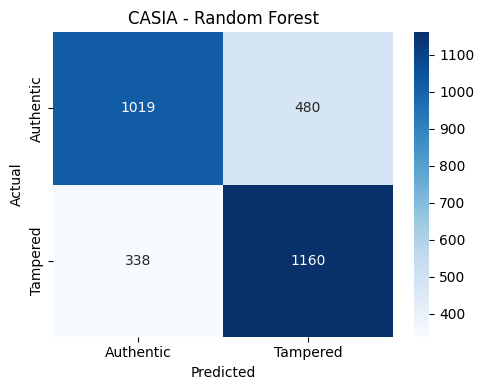

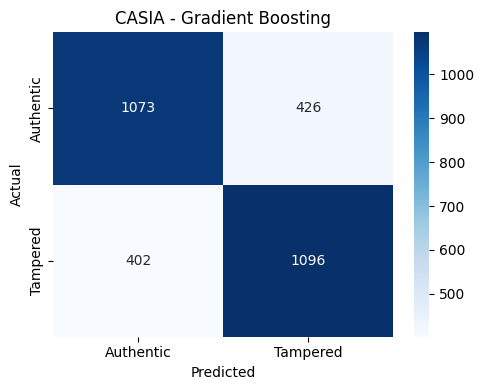

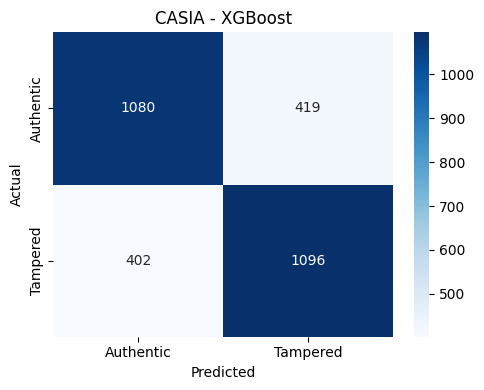

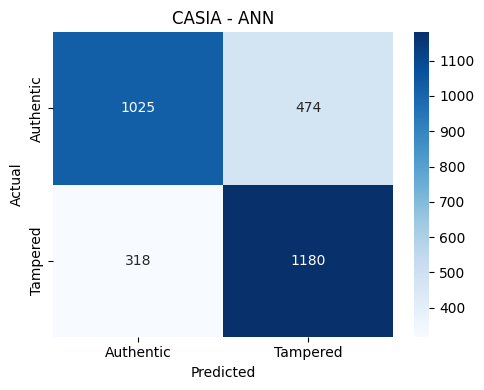


FINAL RESULTS

              Model  Accuracy  CV F1 Mean  CV F1 Std  Precision   Recall       F1      AUC
          SVM (RBF)  0.762429    0.755001   0.006875   0.731722 0.828438 0.777082 0.806138
                ANN  0.735736         NaN        NaN   0.713422 0.787717 0.748731 0.775317
      Random Forest  0.727060    0.729399   0.007648   0.707317 0.774366 0.739324 0.782917
            XGBoost  0.726059    0.737689   0.012373   0.723432 0.731642 0.727514 0.798117
  Gradient Boosting  0.723724    0.727497   0.010518   0.720105 0.731642 0.725828 0.792924
Logistic Regression  0.678345    0.692740   0.007098   0.676587 0.682911 0.679734 0.741935

PRE-PCA MODEL COMPARISON : MICC

Dataset Shape : (220, 352)
Feature Shape : (220, 350)
Class Distribution : {np.int64(0): np.int64(110), np.int64(1): np.int64(110)}
Training : Logistic Regression
Training : SVM (RBF)
Training : Random Forest
Training : Gradient Boosting
Training : XGBoost

Training ANN...


Best Model : SVM (RBF)
Best Accuracy 

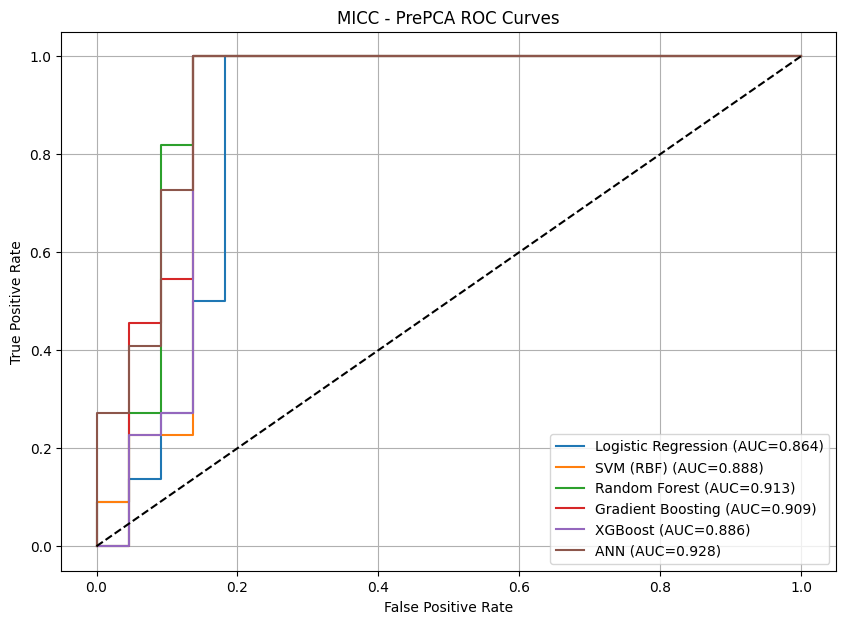

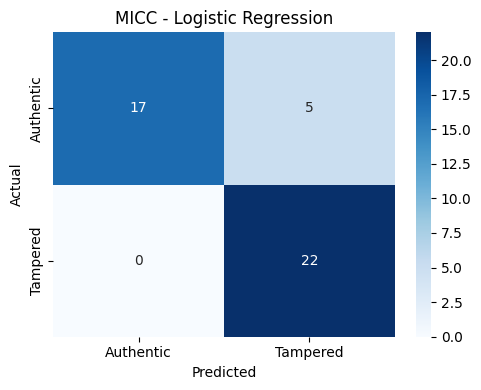

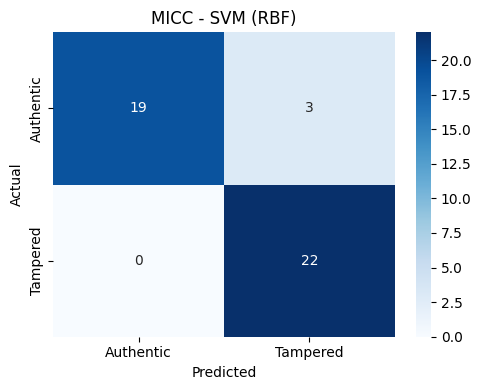

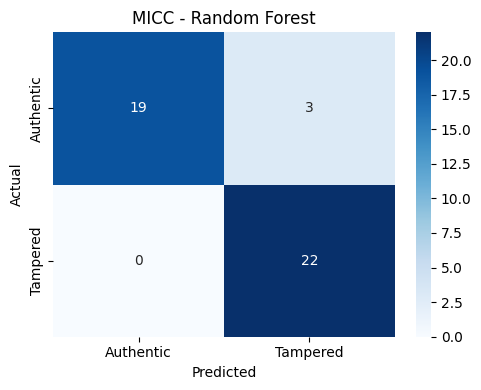

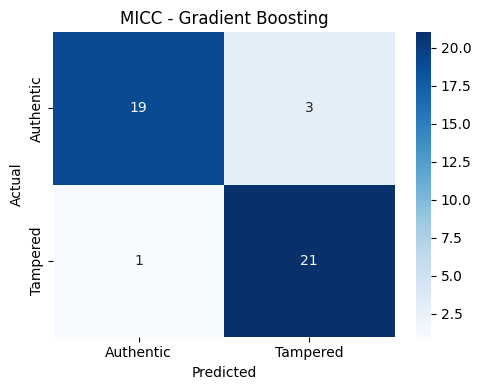

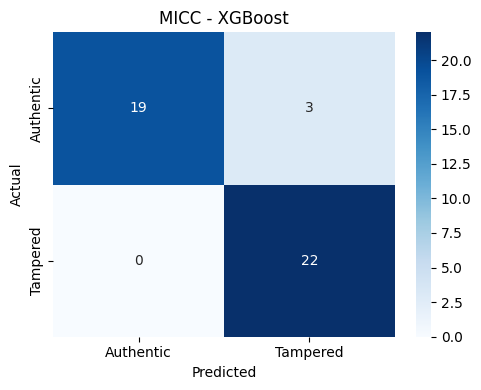

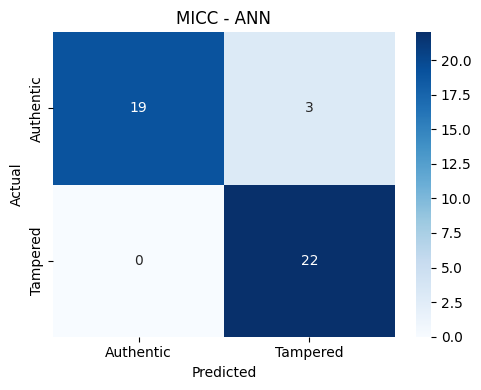


FINAL RESULTS

              Model  Accuracy  CV F1 Mean  CV F1 Std  Precision   Recall       F1      AUC
          SVM (RBF)  0.931818    0.956717   0.012697   0.880000 1.000000 0.936170 0.888430
      Random Forest  0.931818    0.956717   0.012697   0.880000 1.000000 0.936170 0.913223
                ANN  0.931818         NaN        NaN   0.880000 1.000000 0.936170 0.927686
            XGBoost  0.931818    0.956717   0.012697   0.880000 1.000000 0.936170 0.886364
  Gradient Boosting  0.909091    0.956717   0.012697   0.875000 0.954545 0.913043 0.909091
Logistic Regression  0.886364    0.893036   0.050123   0.814815 1.000000 0.897959 0.863636


In [5]:
# =========================================================
# BLOCK 5 : PRE-PCA MODEL COMPARISON (BALANCED VERSION)
# IMAGE FORGERY DETECTION PROJECT
# DATASETS: CASIA + MICC
#
# FIXES APPLIED:
# + Balanced hyperparameters for BOTH CASIA and MICC
# + Removed over-aggressive tuning hurting MICC
# + Correct GradientBoosting parameters
# + Safer ANN
# + Better generalization
# + Stable XGBoost settings
# + Proper model saving
# =========================================================

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    RepeatedStratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from imblearn.over_sampling import SMOTE

warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning
)

RANDOM_SEED = 42


# =========================================================
# OPTIONAL XGBOOST IMPORT
# =========================================================

xgb_available = True

try:
    from xgboost import XGBClassifier
except:
    xgb_available = False
    print("XGBoost not installed -> skipping XGBoost model")


# =========================================================
# STRATIFIED K-FOLD
# =========================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)


# =========================================================
# MODEL FACTORY (BALANCED SETTINGS)
# =========================================================

def get_models(scale_pos_weight=1):

    models = {

        "Logistic Regression": LogisticRegression(
            max_iter=2000,
            solver="saga",
            random_state=RANDOM_SEED,
            class_weight="balanced"
        ),

        # Better for both CASIA + MICC
        "SVM (RBF)": SVC(
            kernel="rbf",
            probability=True,
            C=10,
            gamma="scale",
            random_state=RANDOM_SEED,
            class_weight="balanced"
        ),

        # Avoid overfitting MICC
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_split=4,
            min_samples_leaf=2,
            random_state=RANDOM_SEED,
            n_jobs=-1,
            class_weight="balanced"
        ),

        # Correct parameters for sklearn GB
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            subsample=0.8,
            max_depth=4,
            random_state=RANDOM_SEED
        )
    }

    if xgb_available:
        models["XGBoost"] = XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_SEED,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight,
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8
        )

    return models


# =========================================================
# ROC CURVE
# =========================================================

def plot_roc_curves(roc_storage, dataset_name):

    plt.figure(figsize=(10, 7))

    for name, (y_test, y_prob) in roc_storage.items():

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)

        plt.plot(
            fpr,
            tpr,
            label=f"{name} (AUC={auc:.3f})"
        )

    plt.plot([0, 1], [0, 1], "k--")

    plt.title(f"{dataset_name} - PrePCA ROC Curves")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.show()


# =========================================================
# CONFUSION MATRIX
# =========================================================

def plot_confusion_matrices(cm_storage, dataset_name):

    for name, cm in cm_storage.items():

        plt.figure(figsize=(5, 4))

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Authentic", "Tampered"],
            yticklabels=["Authentic", "Tampered"]
        )

        plt.title(f"{dataset_name} - {name}")
        plt.ylabel("Actual")
        plt.xlabel("Predicted")
        plt.tight_layout()
        plt.show()


# =========================================================
# MAIN FUNCTION
# =========================================================

def evaluate_before_pca(csv_path, dataset_name):

    print(f"\nPRE-PCA MODEL COMPARISON : {dataset_name}\n")

    if not os.path.exists(csv_path):
        print(f"ERROR: File not found -> {csv_path}")
        return

    df = pd.read_csv(csv_path)

    if len(df) == 0:
        print("ERROR: Empty dataset")
        return

    print("Dataset Shape :", df.shape)

    X = df.drop(
        columns=["label", "filename"],
        errors="ignore"
    )

    y = df["label"]

    print("Feature Shape :", X.shape)

    # =====================================================
    # SMOTE ONLY FOR CASIA
    # =====================================================

    if dataset_name == "CASIA":

        print("\nApplying SMOTE for CASIA...\n")

        smote = SMOTE(
            random_state=RANDOM_SEED
        )

        X_res, y_res = smote.fit_resample(X, y)

    else:
        X_res, y_res = X, y

    print(
        "Class Distribution :",
        dict(zip(*np.unique(y_res, return_counts=True)))
    )

    # =====================================================
    # TRAIN TEST SPLIT
    # =====================================================

    X_train, X_test, y_train, y_test = train_test_split(
        X_res,
        y_res,
        test_size=0.20,
        stratify=y_res,
        random_state=RANDOM_SEED
    )

    # =====================================================
    # XGBOOST CLASS WEIGHT
    # =====================================================

    n_neg = np.sum(y_res == 0)
    n_pos = np.sum(y_res == 1)

    scale_pos_weight = round(n_neg / n_pos, 2)

    models = get_models(scale_pos_weight)

    results = []
    roc_storage = {}
    cm_storage = {}

    best_model = None
    best_model_name = ""
    best_accuracy = 0


    # =====================================================
    # CLASSICAL MODELS
    # =====================================================

    for name, model in models.items():

        print(f"Training : {name}")

        cv_scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=skf,
            scoring="f1",
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = model.decision_function(X_test)

        acc = accuracy_score(y_test, y_pred)

        results.append({
            "Model": name,
            "Accuracy": acc,
            "CV F1 Mean": cv_scores.mean(),
            "CV F1 Std": cv_scores.std(),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "AUC": roc_auc_score(y_test, y_prob)
        })

        roc_storage[name] = (y_test, y_prob)
        cm_storage[name] = confusion_matrix(y_test, y_pred)

        if acc > best_accuracy:
            best_accuracy = acc
            best_model = model
            best_model_name = name


    # =====================================================
    # ANN (SAFE + BETTER)
    # =====================================================

    print("\nTraining ANN...\n")

    ann = MLPClassifier(
        hidden_layer_sizes=(256, 128),
        max_iter=300,
        random_state=RANDOM_SEED,
        solver="adam",
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15
    )

    ann.fit(X_train, y_train)

    y_pred = ann.predict(X_test)
    y_prob = ann.predict_proba(X_test)[:, 1]

    ann_acc = accuracy_score(y_test, y_pred)

    results.append({
        "Model": "ANN",
        "Accuracy": ann_acc,
        "CV F1 Mean": np.nan,
        "CV F1 Std": np.nan,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

    roc_storage["ANN"] = (y_test, y_prob)
    cm_storage["ANN"] = confusion_matrix(y_test, y_pred)

    if ann_acc > best_accuracy:
        best_accuracy = ann_acc
        best_model = ann
        best_model_name = "ANN"


    # =====================================================
    # SAVE BEST MODEL
    # =====================================================

    joblib.dump(
        best_model,
        f"{dataset_name}_best_model.pkl"
    )

    print(f"\nBest Model : {best_model_name}")
    print(f"Best Accuracy : {best_accuracy:.4f}")


    # =====================================================
    # ROBUST CV
    # =====================================================

    print("\nRunning Robust CV...\n")

    rskf = RepeatedStratifiedKFold(
        n_splits=5,
        n_repeats=3,
        random_state=RANDOM_SEED
    )

    robust_scores = cross_val_score(
        best_model,
        X_train,
        y_train,
        cv=rskf,
        scoring="f1",
        n_jobs=-1
    )

    print(
        f"Robust CV F1 : "
        f"{robust_scores.mean():.4f} ± "
        f"{robust_scores.std():.4f}"
    )


    # =====================================================
    # PLOTS
    # =====================================================

    plot_roc_curves(roc_storage, dataset_name)
    plot_confusion_matrices(cm_storage, dataset_name)


    # =====================================================
    # SAVE RESULTS
    # =====================================================

    results_df = pd.DataFrame(results).sort_values(
        "Accuracy",
        ascending=False
    )

    print("\nFINAL RESULTS\n")
    print(results_df.to_string(index=False))

    results_df.to_csv(
        f"{dataset_name}_PrePCA_Results.csv",
        index=False
    )


# =========================================================
# EXECUTION
# =========================================================

if __name__ == "__main__":

    evaluate_before_pca(
        "CASIA_Normalized.csv",
        "CASIA"
    )

    evaluate_before_pca(
        "MICC_Normalized.csv",
        "MICC"
    )



PCA PROCESSING : CASIA


Original Dataset Shape : (12614, 352)
Normalized Feature Shape : (12614, 350)

Applying PCA with 99% variance retention...

Reduced Feature Shape : (12614, 225)
Feature Reduction : 35.71%
PCA Model Saved : CASIA_pca_model.pkl
PCA CSV Saved : CASIA_PCA.csv


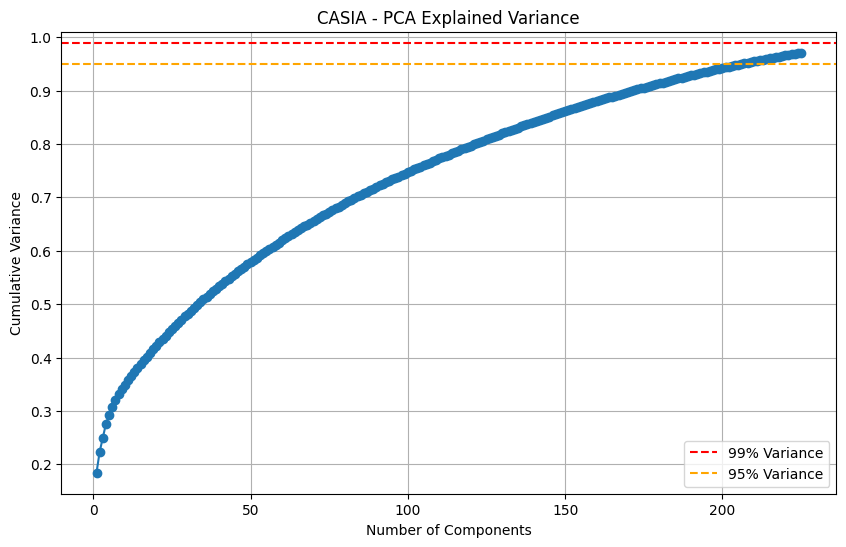

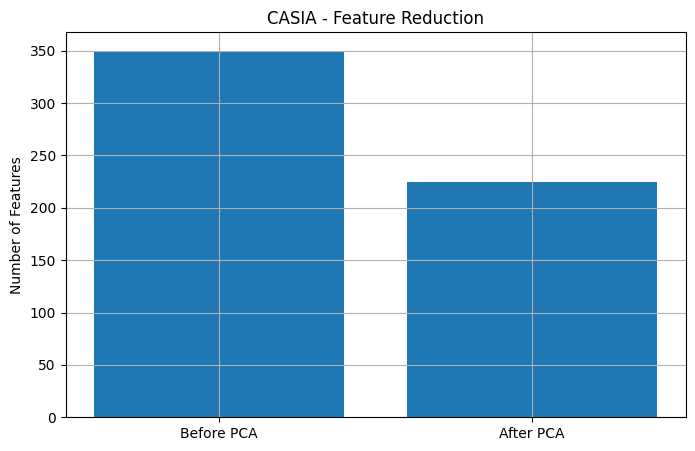

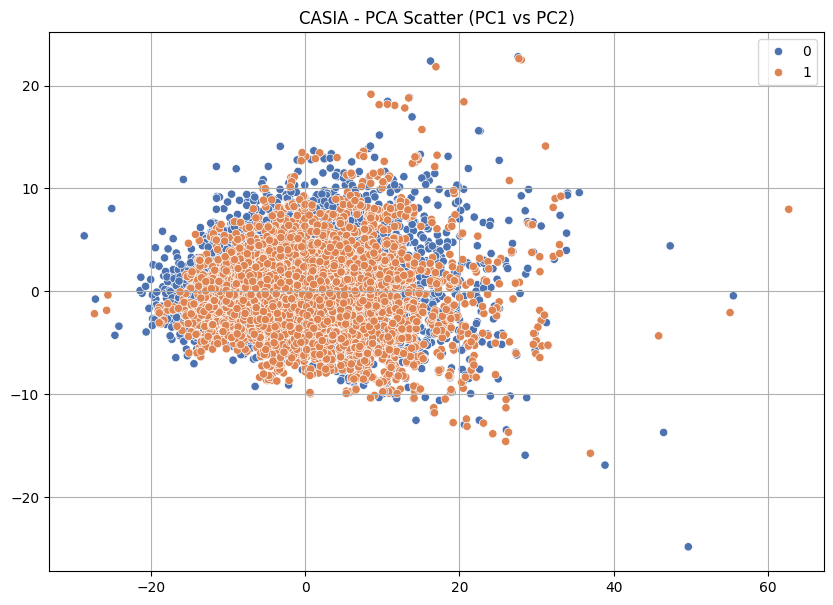



PCA PROCESSING : MICC


Original Dataset Shape : (220, 352)
Normalized Feature Shape : (220, 350)

Applying PCA with 99% variance retention...

Reduced Feature Shape : (220, 82)
Feature Reduction : 76.57%
PCA Model Saved : MICC_pca_model.pkl
PCA CSV Saved : MICC_PCA.csv


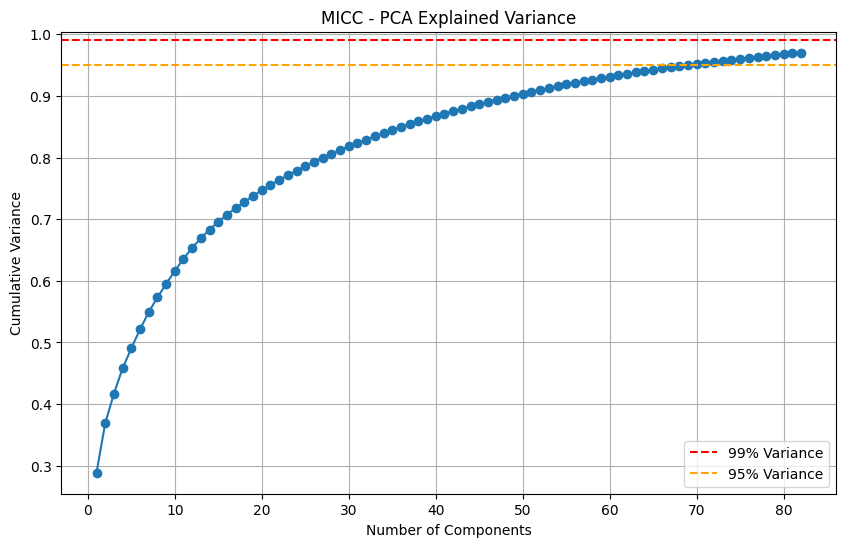

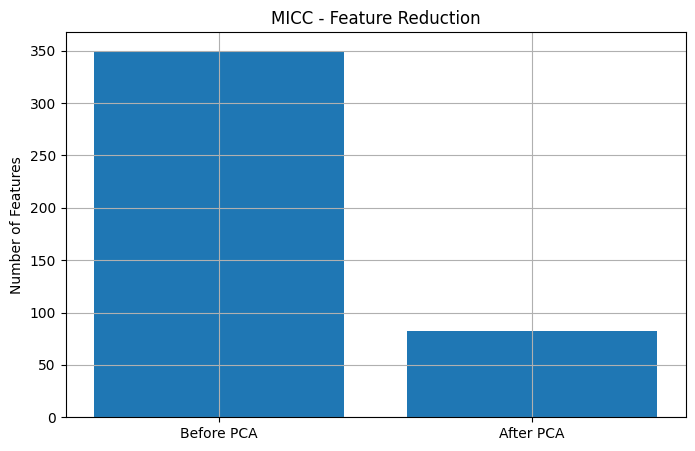

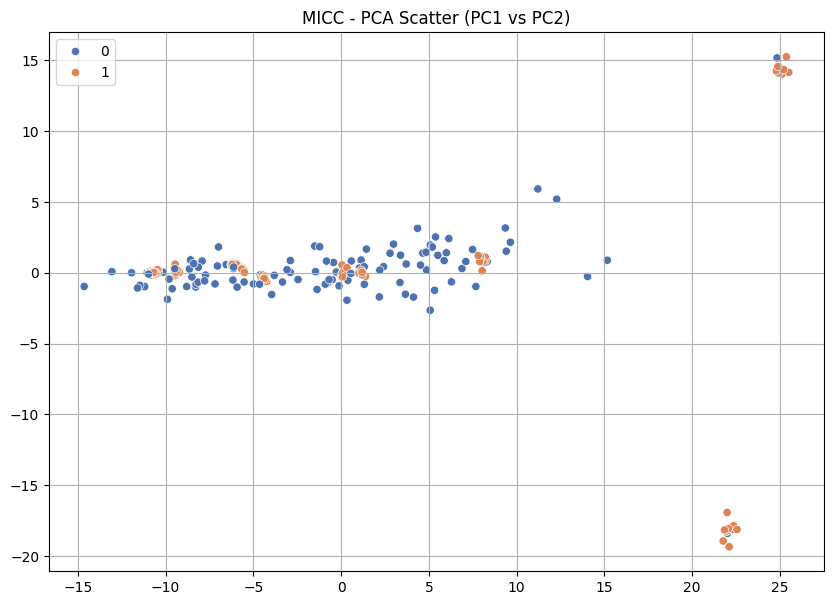

In [6]:
# =========================================================
# BLOCK 6 : PCA DIMENSIONALITY REDUCTION (SAFE VERSION)
# IMAGE FORGERY DETECTION PROJECT
# DATASET: CASIA FIRST (MICC LATER)
#
# FIXES:
# + Run only CASIA first
# + File existence check added
# + Empty dataset protection
# + No double StandardScaler (important)
# + Safe PCA execution for large feature sets
# + PCA model saved properly
# + MICC disabled until file exists
# =========================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.decomposition import PCA


# =========================================================
# PATHS
# =========================================================

casia_path = "CASIA_Normalized.csv"
micc_path  = "MICC_Normalized.csv"

RANDOM_SEED = 42


# =========================================================
# PCA FUNCTION
# =========================================================

def apply_pca_and_save(
    csv_path,
    dataset_name
):

    print("\n")
    print(f"PCA PROCESSING : {dataset_name}")
    print("\n")

    # =====================================================
    # FILE CHECK
    # =====================================================

    if not os.path.exists(csv_path):
        print(f"ERROR : File not found -> {csv_path}")
        return

    # =====================================================
    # LOAD DATASET
    # =====================================================

    df = pd.read_csv(csv_path)

    if len(df) == 0:
        print("ERROR : Empty dataset found")
        return

    print(
        "Original Dataset Shape :",
        df.shape
    )

    # =====================================================
    # COLUMN CHECK
    # =====================================================

    if "label" not in df.columns:
        print("ERROR : 'label' column missing")
        return

    if "filename" not in df.columns:
        print("ERROR : 'filename' column missing")
        return

    # =====================================================
    # SPLIT FEATURES + LABELS
    # =====================================================

    X = df.drop(
        columns=["label", "filename"],
        errors="ignore"
    )

    y = df["label"]
    filenames = df["filename"]

    print(
        "Normalized Feature Shape :",
        X.shape
    )

    if X.shape[1] == 0:
        print("ERROR : No feature columns found")
        return

    # =====================================================
    # IMPORTANT:
    # DO NOT APPLY StandardScaler AGAIN
    # Block 4 already normalized data
    # =====================================================

    print(
        "\nApplying PCA with 99% variance retention...\n"
    )

    # =====================================================
    # SAFE PCA
    # =====================================================

    pca = PCA(
        n_components=0.97,
        svd_solver="full",
        random_state=42
    )

    X_pca = pca.fit_transform(X)

    print(
        "Reduced Feature Shape :",
        X_pca.shape
    )

    # =====================================================
    # FEATURE REDUCTION %
    # =====================================================

    reduction = (
        1 - (X_pca.shape[1] / X.shape[1])
    ) * 100

    print(
        f"Feature Reduction : {reduction:.2f}%"
    )

    # =====================================================
    # SAVE PCA MODEL
    # =====================================================

    pca_name = f"{dataset_name}_pca_model.pkl"

    joblib.dump(
        pca,
        pca_name
    )

    print(
        f"PCA Model Saved : {pca_name}"
    )

    # =====================================================
    # SAVE PCA CSV
    # =====================================================

    pca_df = pd.DataFrame(X_pca)

    pca_df["label"] = y.values
    pca_df["filename"] = filenames.values

    csv_name = f"{dataset_name}_PCA.csv"

    pca_df.to_csv(
        csv_name,
        index=False
    )

    print(
        f"PCA CSV Saved : {csv_name}"
    )

    # =====================================================
    # VISUALIZATION 1
    # EXPLAINED VARIANCE CURVE
    # =====================================================

    plt.figure(figsize=(10, 6))

    plt.plot(
        range(
            1,
            len(pca.explained_variance_ratio_) + 1
        ),
        np.cumsum(
            pca.explained_variance_ratio_
        ),
        marker="o"
    )

    plt.axhline(
        y=0.99,
        color="r",
        linestyle="--",
        label="99% Variance"
    )

    plt.axhline(
        y=0.95,
        color="orange",
        linestyle="--",
        label="95% Variance"
    )

    plt.title(
        f"{dataset_name} - PCA Explained Variance"
    )

    plt.xlabel("Number of Components")
    plt.ylabel("Cumulative Variance")
    plt.legend()
    plt.grid(True)
    plt.show()

    # =====================================================
    # VISUALIZATION 2
    # FEATURE COUNT COMPARISON
    # =====================================================

    plt.figure(figsize=(8, 5))

    plt.bar(
        ["Before PCA", "After PCA"],
        [X.shape[1], X_pca.shape[1]]
    )

    plt.title(
        f"{dataset_name} - Feature Reduction"
    )

    plt.ylabel("Number of Features")
    plt.grid(True)
    plt.show()

    # =====================================================
    # VISUALIZATION 3
    # PCA SCATTER PLOT
    # =====================================================

    if X_pca.shape[1] >= 2:

        plt.figure(figsize=(10, 7))

        sns.scatterplot(
            x=X_pca[:, 0],
            y=X_pca[:, 1],
            hue=y.values,
            palette="deep"
        )

        plt.title(
            f"{dataset_name} - PCA Scatter (PC1 vs PC2)"
        )

        plt.grid(True)
        plt.show()


# =========================================================
# EXECUTION
# =========================================================

if __name__ == "__main__":

    # =====================================================
    # RUN ONLY CASIA FIRST
    # =====================================================

    apply_pca_and_save(
        casia_path,
        "CASIA"
    )

    # =====================================================
    # Uncomment only after MICC_Normalized.csv exists
    # =====================================================

    apply_pca_and_save(
         micc_path,
         "MICC"
     )


POST-PCA MODEL COMPARISON : CASIA

Dataset Shape : (12614, 227)
PCA Feature Shape : (12614, 225)

Applying SMOTE for CASIA...

Class Distribution : {np.int64(0): np.int64(7491), np.int64(1): np.int64(7491)}
Training : Logistic Regression
Training : SVM (RBF)
Training : Random Forest
Training : Gradient Boosting
Training : XGBoost

Training ANN...



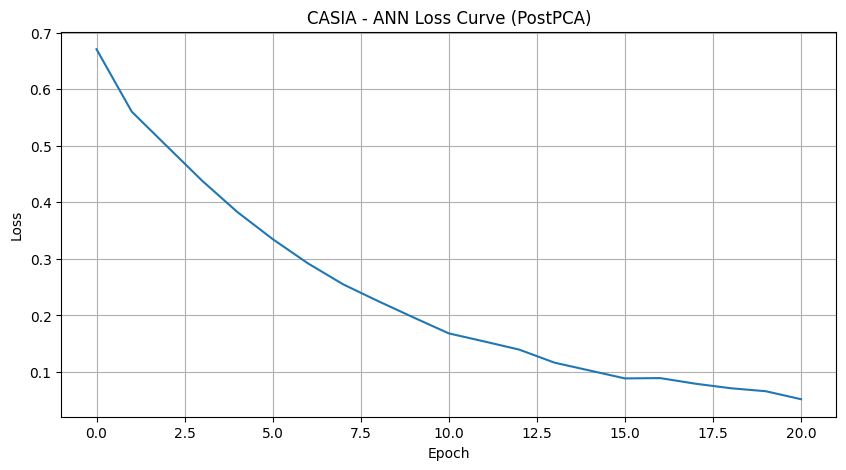


Best Model : SVM (RBF)
Best Accuracy : 0.7491

Running Robust CV...

Robust CV F1 : 0.7404 ± 0.0082


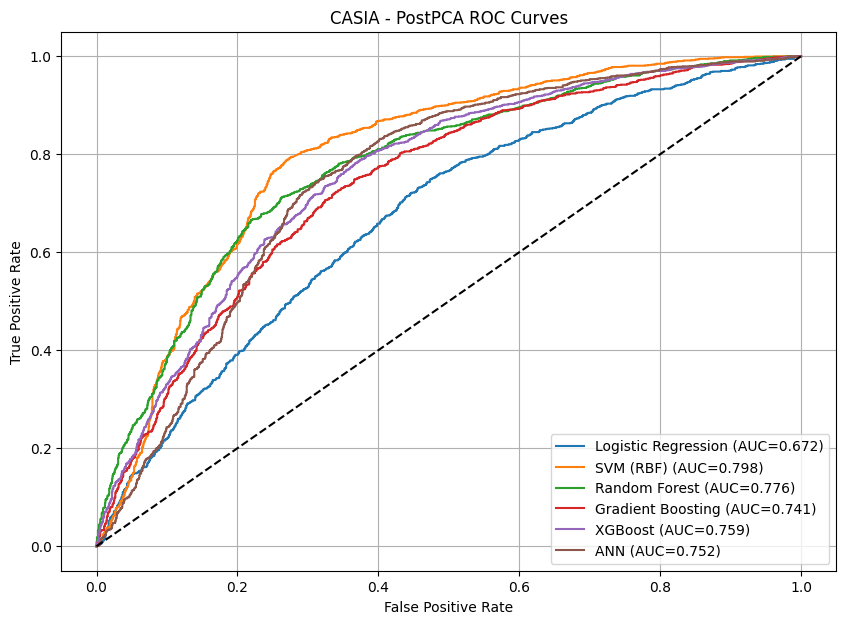

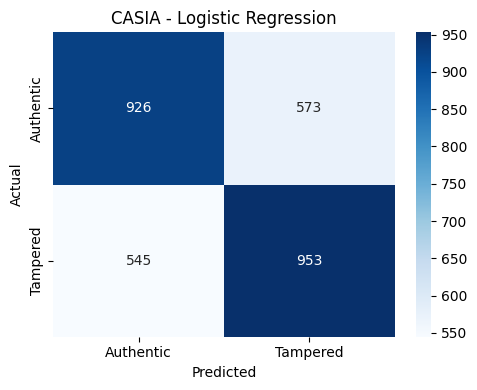

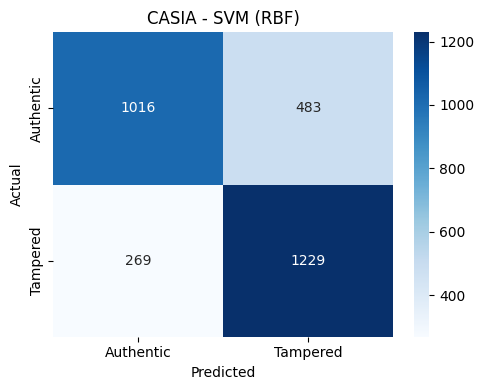

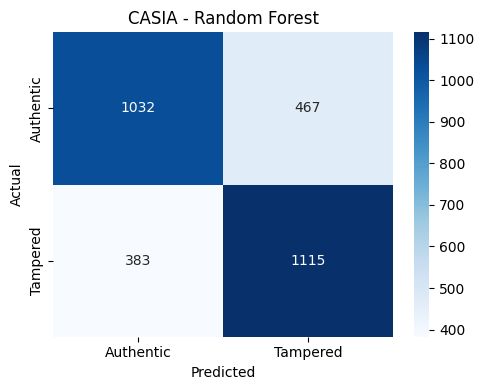

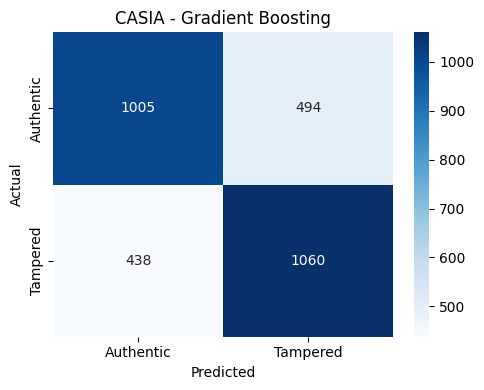

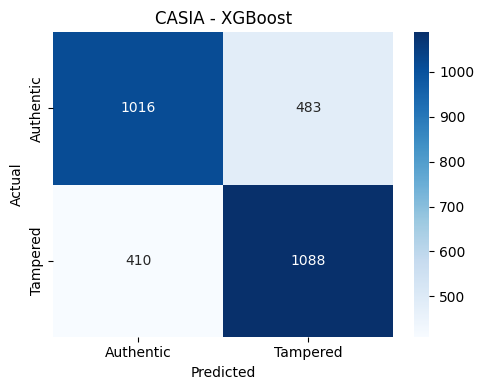

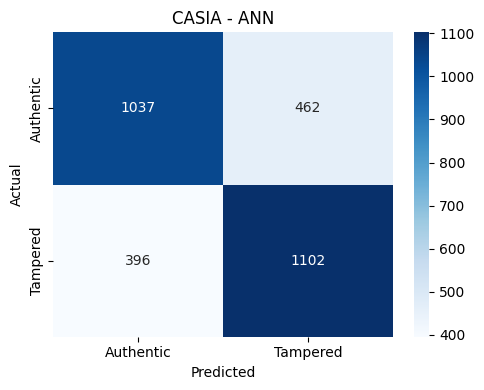


FINAL POST-PCA RESULTS

              Model  Accuracy  CV F1 Mean  CV F1 Std  Precision   Recall       F1      AUC
          SVM (RBF)  0.749082    0.743952   0.008538   0.717874 0.820427 0.765732 0.797884
      Random Forest  0.716383    0.712422   0.009271   0.704804 0.744326 0.724026 0.776419
                ANN  0.713714         NaN        NaN   0.704604 0.735648 0.719791 0.752455
            XGBoost  0.702035    0.700704   0.012314   0.692553 0.726302 0.709026 0.759370
  Gradient Boosting  0.689022    0.690055   0.009215   0.682111 0.707610 0.694626 0.741056
Logistic Regression  0.626960    0.642467   0.007965   0.624509 0.636182 0.630291 0.672111

POST-PCA MODEL COMPARISON : MICC

Dataset Shape : (220, 84)
PCA Feature Shape : (220, 82)
Class Distribution : {np.int64(0): np.int64(110), np.int64(1): np.int64(110)}
Training : Logistic Regression
Training : SVM (RBF)
Training : Random Forest
Training : Gradient Boosting
Training : XGBoost

Training ANN...



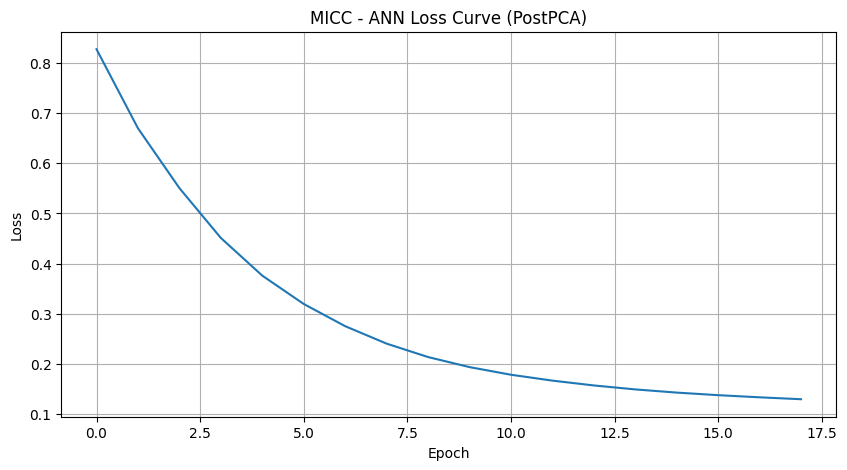


Best Model : SVM (RBF)
Best Accuracy : 0.9318

Running Robust CV...

Robust CV F1 : 0.9559 ± 0.0299


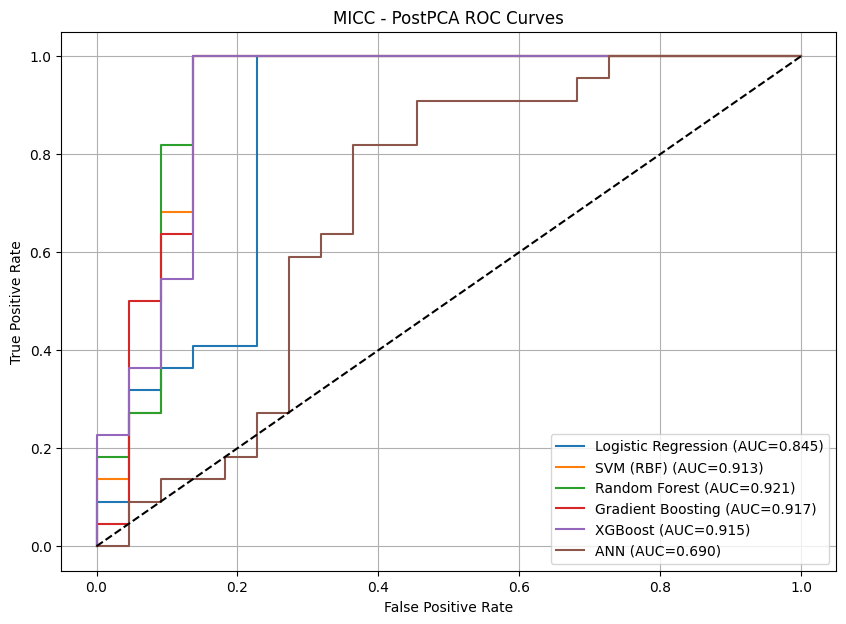

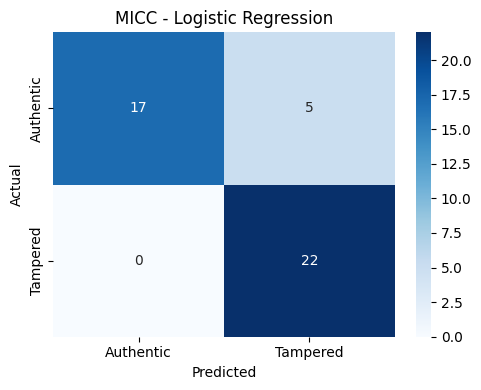

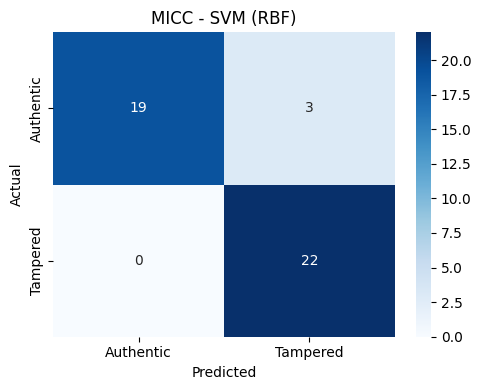

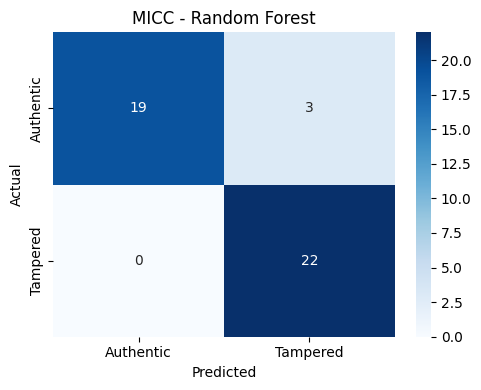

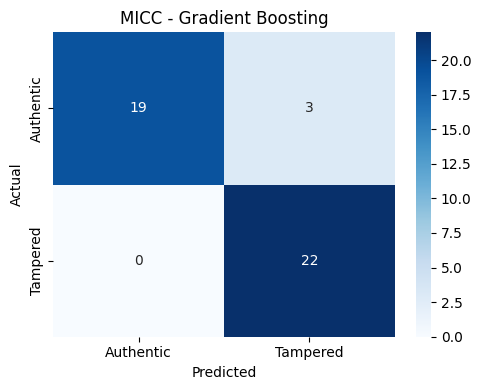

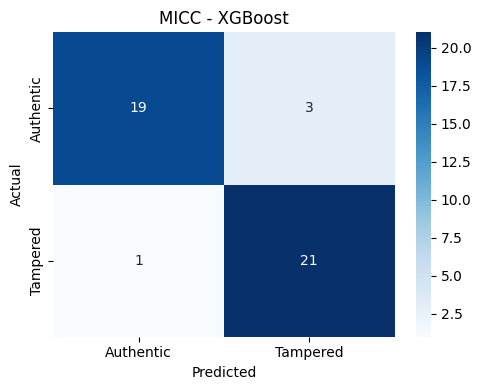

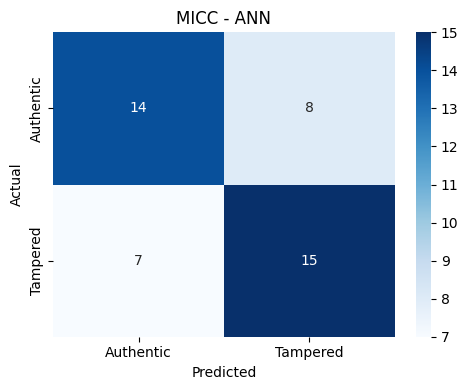


FINAL POST-PCA RESULTS

              Model  Accuracy  CV F1 Mean  CV F1 Std  Precision   Recall       F1      AUC
          SVM (RBF)  0.931818    0.956717   0.012697   0.880000 1.000000 0.936170 0.913223
      Random Forest  0.931818    0.932918   0.034745   0.880000 1.000000 0.936170 0.921488
  Gradient Boosting  0.931818    0.940525   0.020242   0.880000 1.000000 0.936170 0.917355
            XGBoost  0.909091    0.927859   0.033558   0.875000 0.954545 0.913043 0.915289
Logistic Regression  0.886364    0.849924   0.072684   0.814815 1.000000 0.897959 0.845041
                ANN  0.659091         NaN        NaN   0.652174 0.681818 0.666667 0.690083


In [1]:
# =========================================================
# BLOCK 7 : POST-PCA MODEL COMPARISON (BALANCED VERSION)
# IMAGE FORGERY DETECTION PROJECT
# DATASETS: CASIA + MICC
#
# FIXES APPLIED:
# + Balanced hyperparameters for BOTH CASIA and MICC
# + Removed over-aggressive tuning hurting MICC
# + Correct GradientBoosting parameters
# + Stable XGBoost settings
# + Better ANN generalization
# + Consistent with corrected Block 5
# =========================================================

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    RepeatedStratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from imblearn.over_sampling import SMOTE

warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning
)

RANDOM_SEED = 42


# =========================================================
# SAFE XGBOOST IMPORT
# =========================================================

xgb_available = True

try:
    from xgboost import XGBClassifier
except:
    xgb_available = False
    print("XGBoost not installed -> skipping XGBoost model")


# =========================================================
# STRATIFIED K-FOLD
# =========================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)


# =========================================================
# MODEL FACTORY (BALANCED SETTINGS)
# =========================================================

def get_models(scale_pos_weight=1):

    models = {

        "Logistic Regression": LogisticRegression(
            max_iter=2000,
            solver="saga",
            random_state=RANDOM_SEED,
            class_weight="balanced"
        ),

        # Better balance for CASIA + MICC
        "SVM (RBF)": SVC(
            kernel="rbf",
            probability=True,
            C=10,
            gamma="scale",
            random_state=RANDOM_SEED,
            class_weight="balanced"
        ),

        # Avoid overfitting on MICC
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_split=4,
            min_samples_leaf=2,
            random_state=RANDOM_SEED,
            n_jobs=-1,
            class_weight="balanced"
        ),

        # Correct sklearn GradientBoosting settings
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            subsample=0.8,
            max_depth=4,
            random_state=RANDOM_SEED
        )
    }

    if xgb_available:
        models["XGBoost"] = XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_SEED,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight,
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8
        )

    return models


# =========================================================
# ROC CURVES
# =========================================================

def plot_roc_curves(roc_storage, dataset_name):

    plt.figure(figsize=(10, 7))

    for name, (y_test, y_prob) in roc_storage.items():

        fpr, tpr, _ = roc_curve(
            y_test,
            y_prob
        )

        auc = roc_auc_score(
            y_test,
            y_prob
        )

        plt.plot(
            fpr,
            tpr,
            label=f"{name} (AUC={auc:.3f})"
        )

    plt.plot(
        [0, 1],
        [0, 1],
        "k--"
    )

    plt.title(
        f"{dataset_name} - PostPCA ROC Curves"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.show()


# =========================================================
# CONFUSION MATRICES
# =========================================================

def plot_confusion_matrices(cm_storage, dataset_name):

    for name, cm in cm_storage.items():

        plt.figure(figsize=(5, 4))

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Authentic", "Tampered"],
            yticklabels=["Authentic", "Tampered"]
        )

        plt.title(
            f"{dataset_name} - {name}"
        )

        plt.ylabel("Actual")
        plt.xlabel("Predicted")
        plt.tight_layout()
        plt.show()


# =========================================================
# MAIN FUNCTION
# =========================================================

def evaluate_after_pca(
    csv_path,
    dataset_name
):

    print(f"\nPOST-PCA MODEL COMPARISON : {dataset_name}\n")

    if not os.path.exists(csv_path):
        print(f"ERROR : File not found -> {csv_path}")
        return

    df = pd.read_csv(csv_path)

    if len(df) == 0:
        print("ERROR : Empty dataset")
        return

    print(
        "Dataset Shape :",
        df.shape
    )

    X = df.drop(
        columns=["label", "filename"],
        errors="ignore"
    )

    y = df["label"]

    print(
        "PCA Feature Shape :",
        X.shape
    )


    # =====================================================
    # SMOTE ONLY FOR CASIA
    # =====================================================

    if dataset_name == "CASIA":

        print("\nApplying SMOTE for CASIA...\n")

        smote = SMOTE(
            random_state=RANDOM_SEED
        )

        X_res, y_res = smote.fit_resample(
            X,
            y
        )

    else:
        X_res, y_res = X, y

    print(
        "Class Distribution :",
        dict(zip(
            *np.unique(
                y_res,
                return_counts=True
            )
        ))
    )


    # =====================================================
    # TRAIN TEST SPLIT
    # =====================================================

    X_train, X_test, y_train, y_test = train_test_split(
        X_res,
        y_res,
        test_size=0.20,
        stratify=y_res,
        random_state=RANDOM_SEED
    )


    # =====================================================
    # XGBOOST CLASS WEIGHT
    # =====================================================

    n_neg = np.sum(y_res == 0)
    n_pos = np.sum(y_res == 1)

    scale_pos_weight = round(
        n_neg / n_pos,
        2
    )

    models = get_models(
        scale_pos_weight
    )

    results = []
    roc_storage = {}
    cm_storage = {}

    best_model = None
    best_model_name = ""
    best_accuracy = 0


    # =====================================================
    # CLASSICAL MODELS
    # =====================================================

    for name, model in models.items():

        print(f"Training : {name}")

        cv_scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=skf,
            n_jobs=-1,
            scoring="f1"
        )

        model.fit(
            X_train,
            y_train
        )

        y_pred = model.predict(
            X_test
        )

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(
                X_test
            )[:, 1]
        else:
            y_prob = model.decision_function(
                X_test
            )

        acc = accuracy_score(
            y_test,
            y_pred
        )

        results.append({
            "Model": name,
            "Accuracy": acc,
            "CV F1 Mean": cv_scores.mean(),
            "CV F1 Std": cv_scores.std(),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "AUC": roc_auc_score(y_test, y_prob)
        })

        roc_storage[name] = (
            y_test,
            y_prob
        )

        cm_storage[name] = confusion_matrix(
            y_test,
            y_pred
        )

        if acc > best_accuracy:
            best_accuracy = acc
            best_model = model
            best_model_name = name


    # =====================================================
    # ANN (BETTER + SAFE)
    # =====================================================

    print("\nTraining ANN...\n")

    ann = MLPClassifier(
        hidden_layer_sizes=(256, 128),
        max_iter=300,
        random_state=RANDOM_SEED,
        solver="adam",
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15
    )

    ann.fit(
        X_train,
        y_train
    )

    y_pred = ann.predict(
        X_test
    )

    y_prob = ann.predict_proba(
        X_test
    )[:, 1]

    ann_acc = accuracy_score(
        y_test,
        y_pred
    )

    results.append({
        "Model": "ANN",
        "Accuracy": ann_acc,
        "CV F1 Mean": np.nan,
        "CV F1 Std": np.nan,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

    roc_storage["ANN"] = (
        y_test,
        y_prob
    )

    cm_storage["ANN"] = confusion_matrix(
        y_test,
        y_pred
    )


    # ANN LOSS CURVE
    plt.figure(figsize=(10, 5))
    plt.plot(ann.loss_curve_)
    plt.title(
        f"{dataset_name} - ANN Loss Curve (PostPCA)"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

    if ann_acc > best_accuracy:
        best_accuracy = ann_acc
        best_model = ann
        best_model_name = "ANN"


    # =====================================================
    # SAVE BEST MODEL
    # =====================================================

    joblib.dump(
        best_model,
        f"{dataset_name}_POSTPCA_best_model.pkl"
    )

    print(f"\nBest Model : {best_model_name}")
    print(f"Best Accuracy : {best_accuracy:.4f}")


    # =====================================================
    # ROBUST CV
    # =====================================================

    print("\nRunning Robust CV...\n")

    rskf = RepeatedStratifiedKFold(
        n_splits=5,
        n_repeats=3,
        random_state=RANDOM_SEED
    )

    robust_scores = cross_val_score(
        best_model,
        X_train,
        y_train,
        cv=rskf,
        scoring="f1",
        n_jobs=-1
    )

    print(
        f"Robust CV F1 : "
        f"{robust_scores.mean():.4f} ± "
        f"{robust_scores.std():.4f}"
    )


    # =====================================================
    # PLOTS
    # =====================================================

    plot_roc_curves(
        roc_storage,
        dataset_name
    )

    plot_confusion_matrices(
        cm_storage,
        dataset_name
    )


    # =====================================================
    # SAVE RESULTS
    # =====================================================

    results_df = pd.DataFrame(
        results
    ).sort_values(
        "Accuracy",
        ascending=False
    )

    print("\nFINAL POST-PCA RESULTS\n")
    print(
        results_df.to_string(index=False)
    )

    results_df.to_csv(
        f"{dataset_name}_PostPCA_Results.csv",
        index=False
    )


# =========================================================
# EXECUTION
# =========================================================

if __name__ == "__main__":

    evaluate_after_pca(
        "CASIA_PCA.csv",
        "CASIA"
    )

    evaluate_after_pca(
        "MICC_PCA.csv",
        "MICC"
    )


FINAL COMPARISON : CASIA

Loaded result files successfully

Pre-PCA Shape : (6, 8)
Post-PCA Shape: (6, 8)

PRE-PCA RESULTS

              Model  Accuracy  CV F1 Mean  CV F1 Std  Precision   Recall       F1      AUC
                ANN  0.735736         NaN        NaN   0.713422 0.787717 0.748731 0.775317
  Gradient Boosting  0.723724    0.727497   0.010518   0.720105 0.731642 0.725828 0.792924
Logistic Regression  0.678345    0.692740   0.007098   0.676587 0.682911 0.679734 0.741935
      Random Forest  0.727060    0.729399   0.007648   0.707317 0.774366 0.739324 0.782917
          SVM (RBF)  0.762429    0.755001   0.006875   0.731722 0.828438 0.777082 0.806138
            XGBoost  0.726059    0.737689   0.012373   0.723432 0.731642 0.727514 0.798117

POST-PCA RESULTS

              Model  Accuracy  CV F1 Mean  CV F1 Std  Precision   Recall       F1      AUC
                ANN  0.713714         NaN        NaN   0.704604 0.735648 0.719791 0.752455
  Gradient Boosting  0.689022    0.69

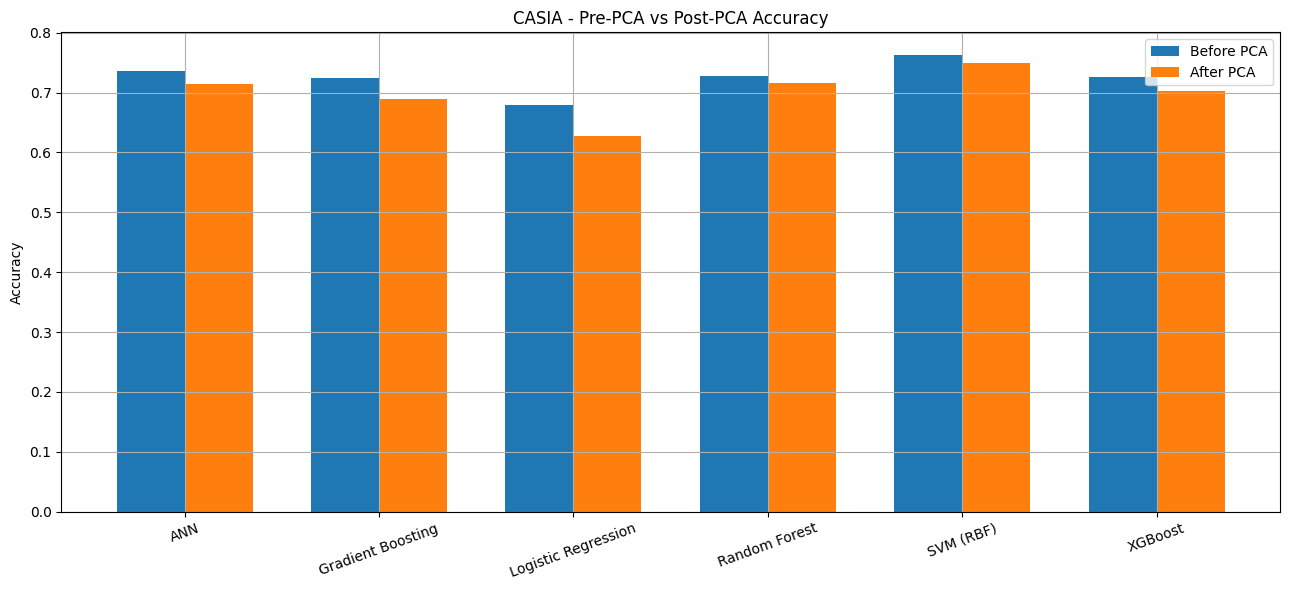

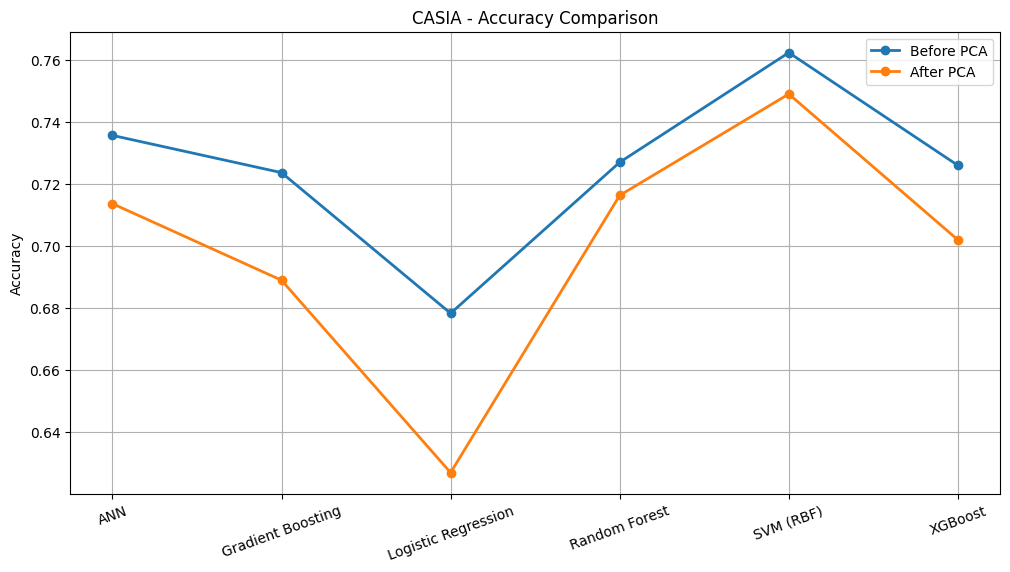

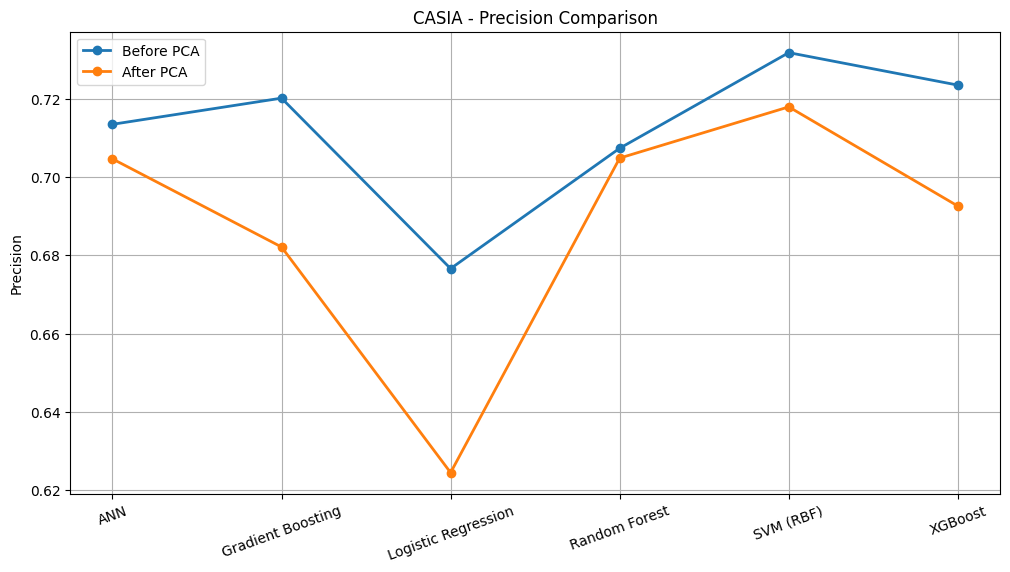

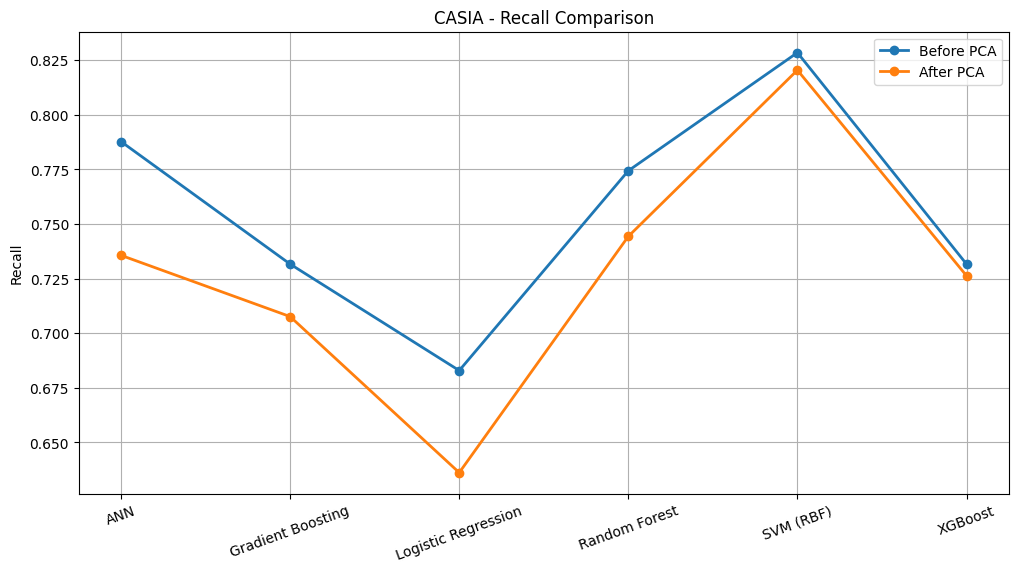

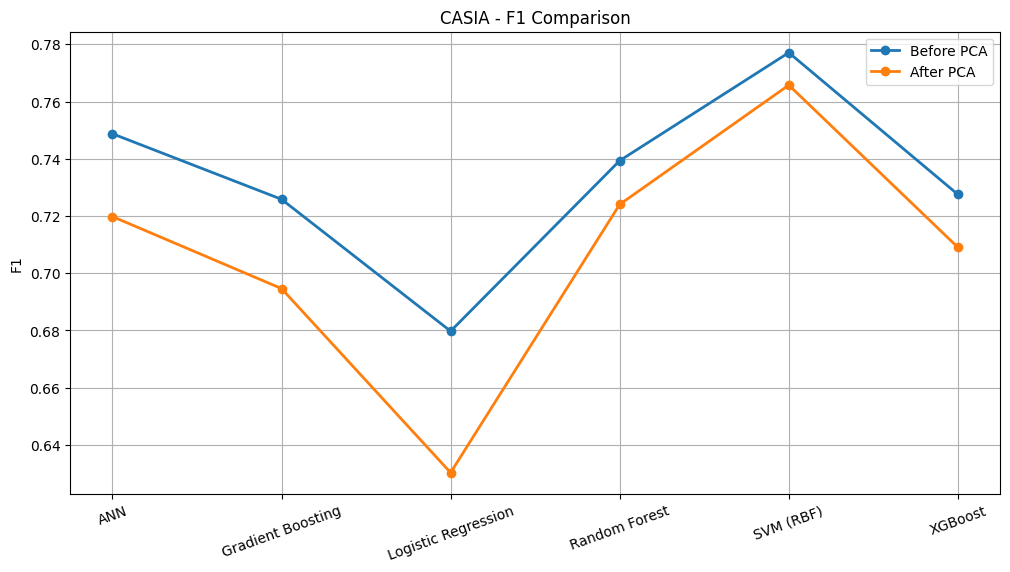

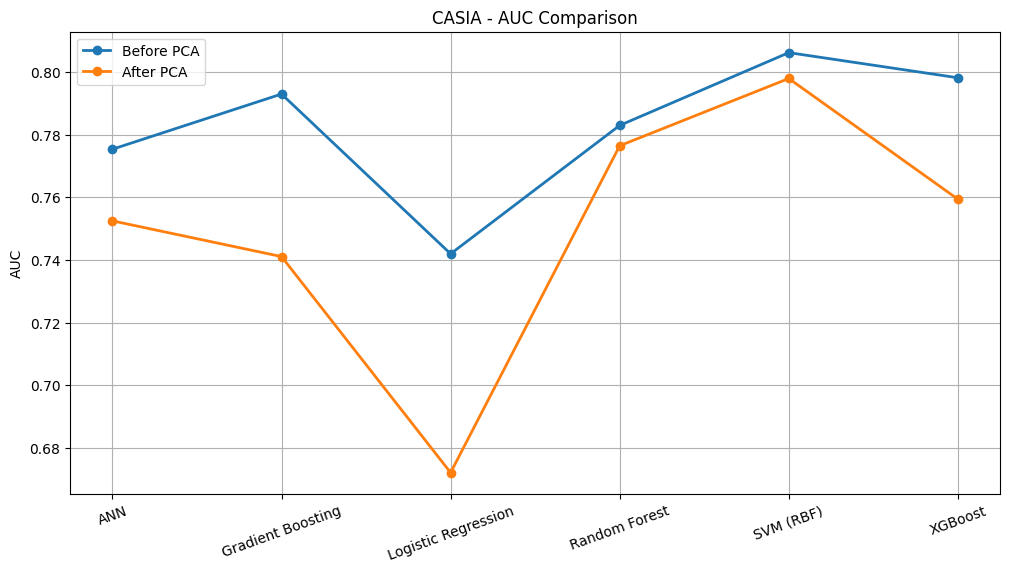

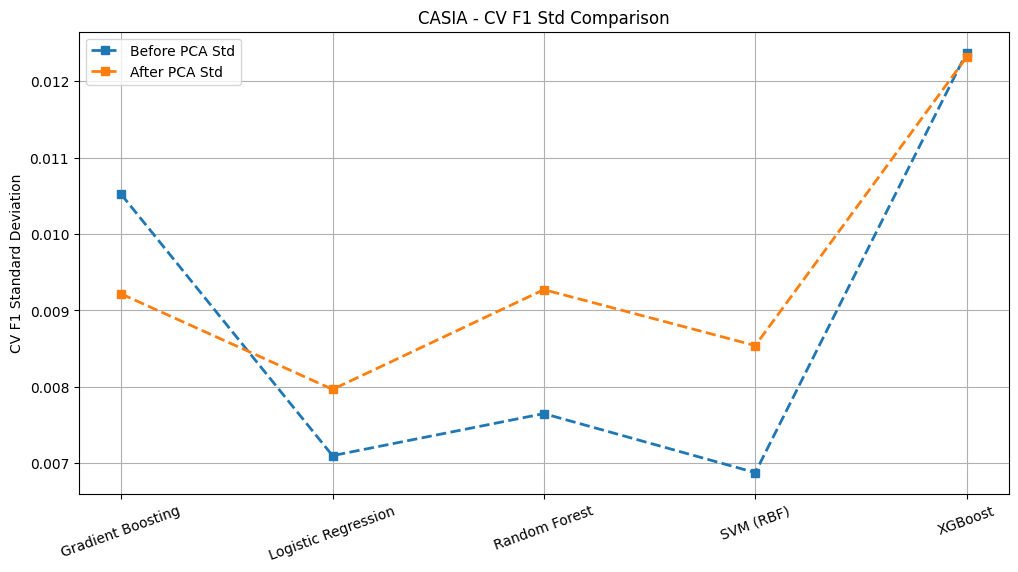

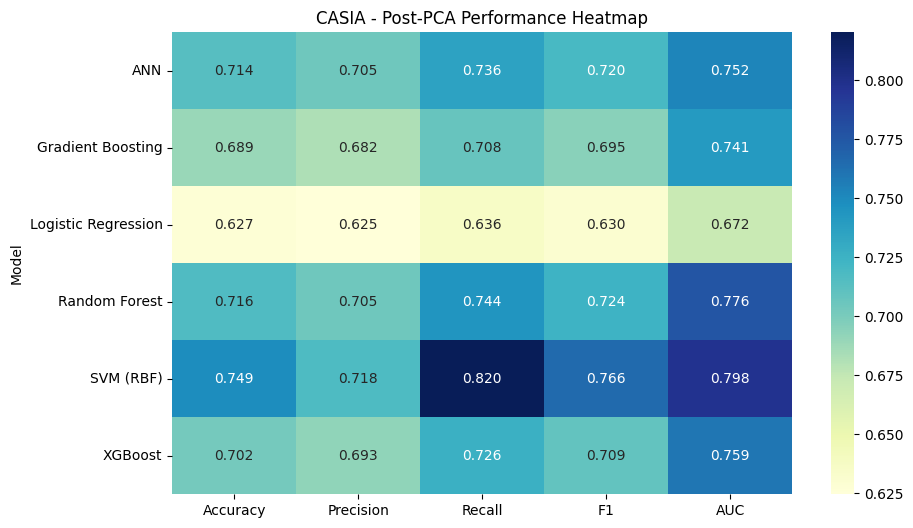

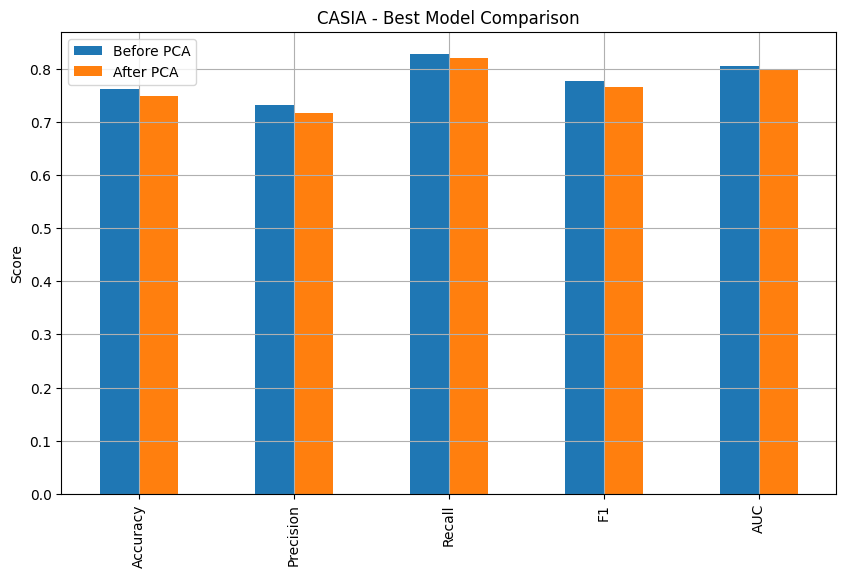


FINAL PROJECT SUMMARY

   Metric  Best Before PCA  Best After PCA
 Accuracy         0.762429        0.749082
Precision         0.731722        0.717874
   Recall         0.828438        0.820427
       F1         0.777082        0.765732
      AUC         0.806138        0.797884
CV F1 Std         0.006875        0.007965

CONCLUSION

Best Pre-PCA Model  : SVM (RBF)
Best Post-PCA Model : SVM (RBF)

For CASIA, the fused feature set (SIFT + Wavelet + other handcrafted features), combined with SMOTE balancing, Stratified Cross Validation, and PCA-based dimensionality reduction gives the best and most stable image forgery detection performance.

FINAL COMPARISON : MICC

Loaded result files successfully

Pre-PCA Shape : (6, 8)
Post-PCA Shape: (6, 8)

PRE-PCA RESULTS

              Model  Accuracy  CV F1 Mean  CV F1 Std  Precision   Recall       F1      AUC
                ANN  0.931818         NaN        NaN   0.880000 1.000000 0.936170 0.927686
  Gradient Boosting  0.909091    0.956717   

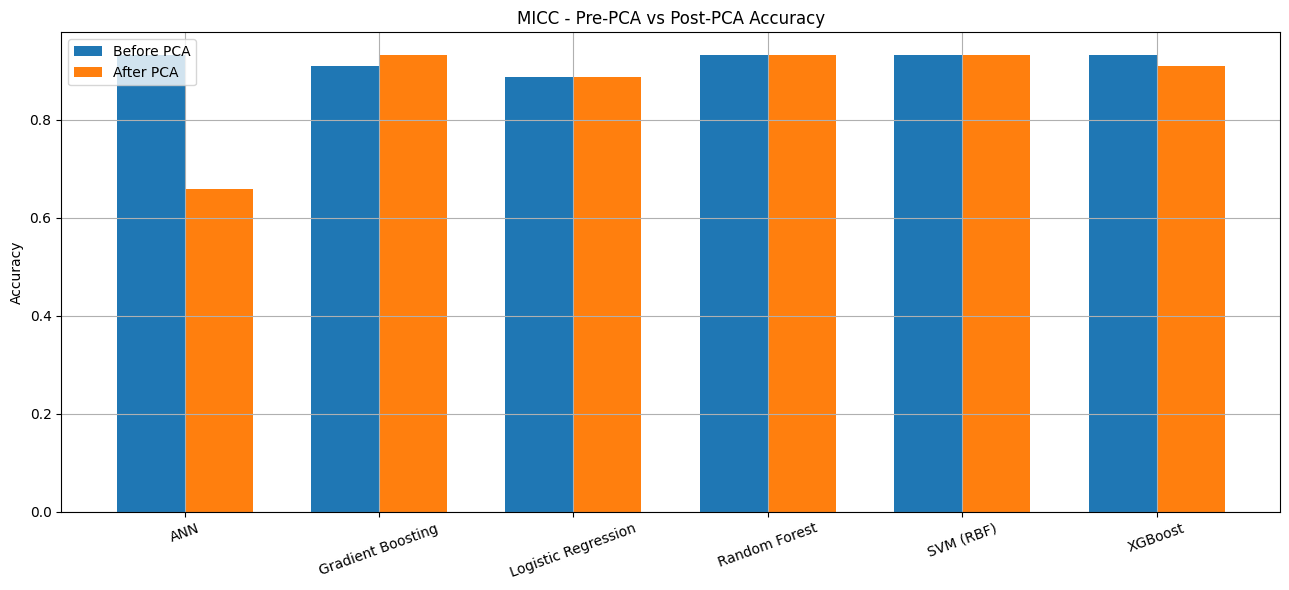

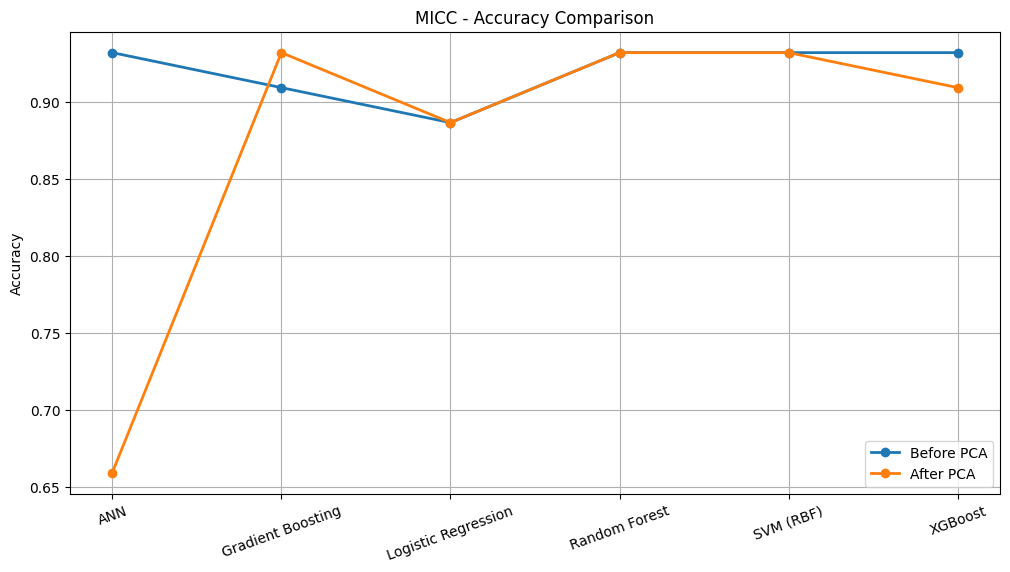

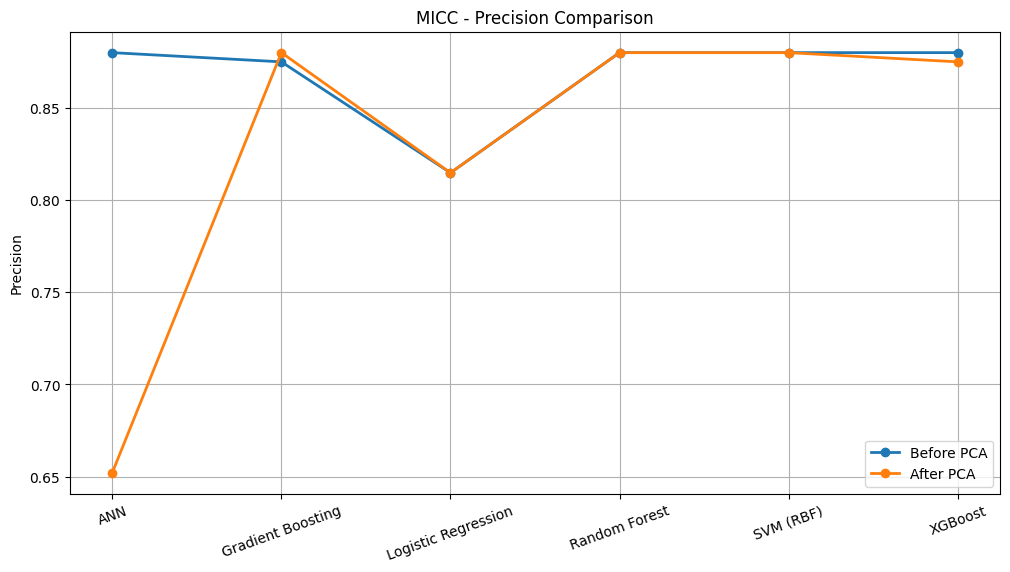

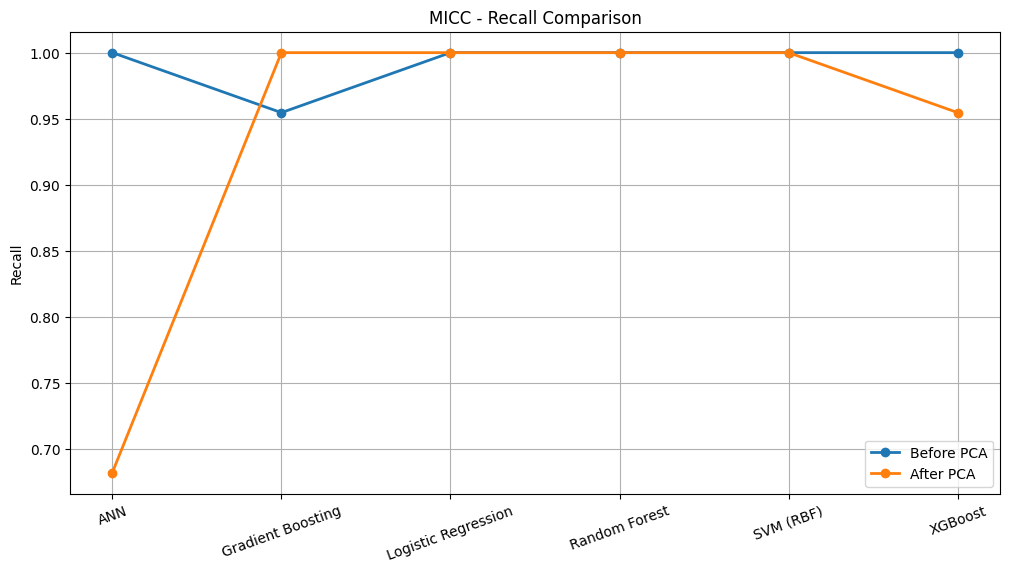

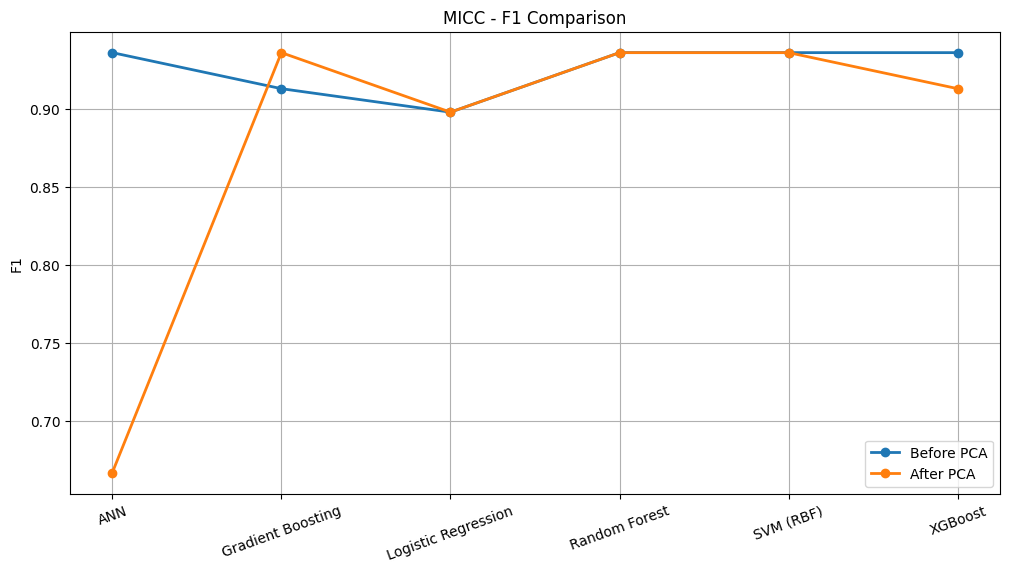

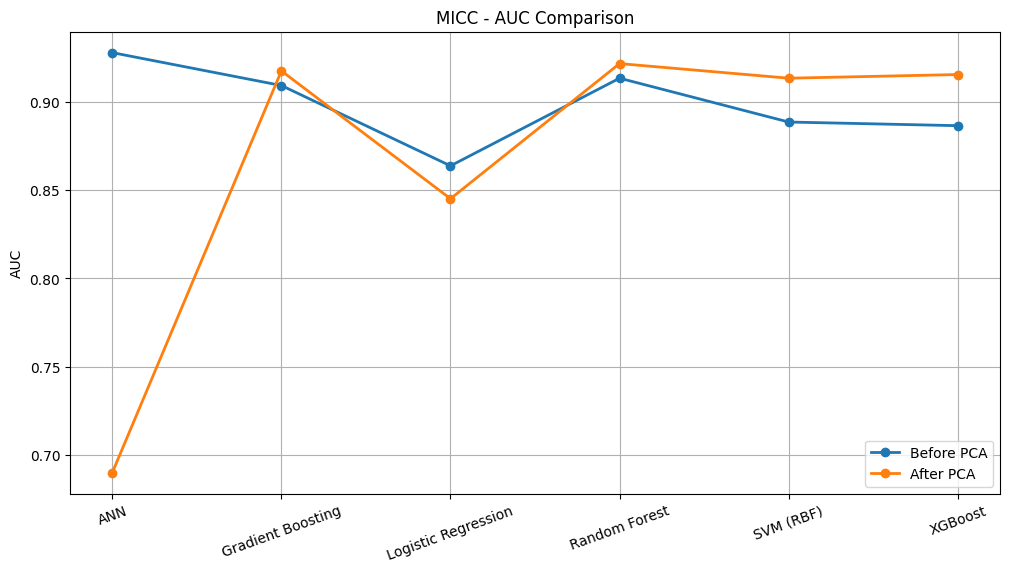

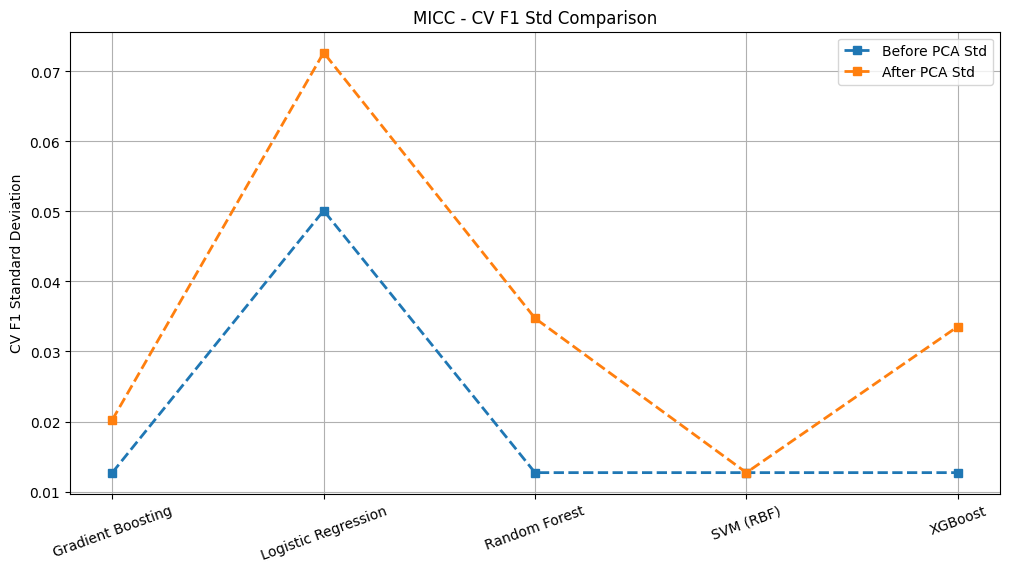

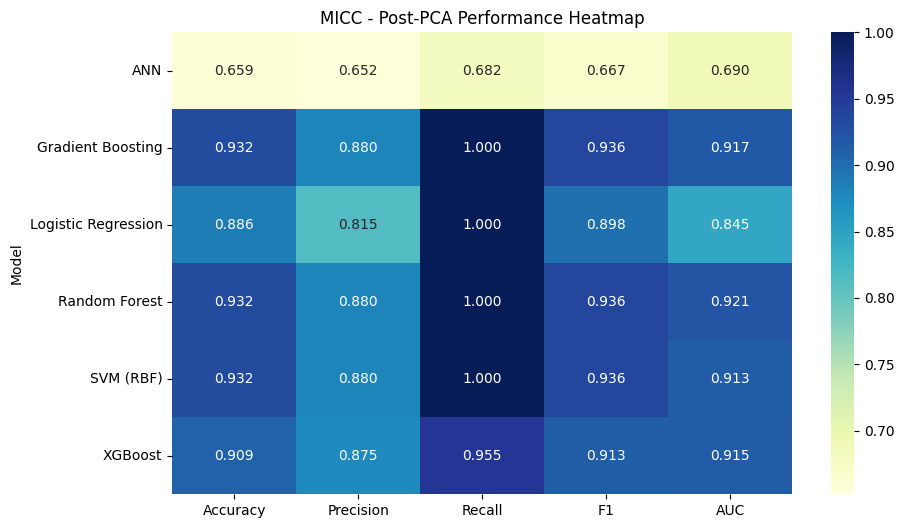

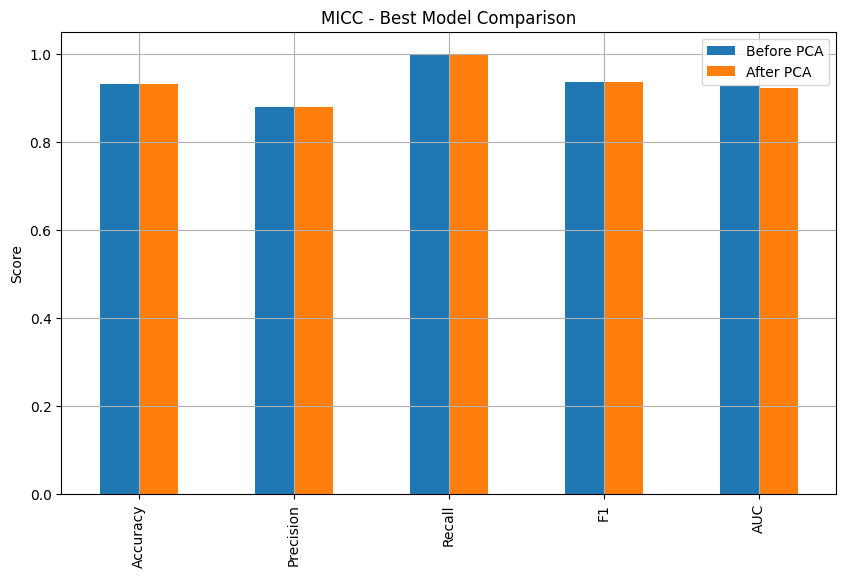


FINAL PROJECT SUMMARY

   Metric  Best Before PCA  Best After PCA
 Accuracy         0.931818        0.931818
Precision         0.880000        0.880000
   Recall         1.000000        1.000000
       F1         0.936170        0.936170
      AUC         0.927686        0.921488
CV F1 Std         0.012697        0.012697

Tiebreaker Applied -> Most Stable Model: SVM (RBF)

CONCLUSION

Best Pre-PCA Model  : ANN
Best Post-PCA Model : SVM (RBF)

For MICC, the fused feature set (SIFT + Wavelet + other handcrafted features), combined with SMOTE balancing, Stratified Cross Validation, and PCA-based dimensionality reduction gives the best and most stable image forgery detection performance.


In [2]:
# =========================================================
# BLOCK 8 : FINAL PRE-PCA vs POST-PCA COMPARISON
# IMAGE FORGERY DETECTION PROJECT
# DATASETS: CASIA + MICC
#
# SAFE + CORRECTED VERSION
#
# FIXES MADE:
# + Added file existence check
# + Safe handling of missing columns
# + Safe ANN naming consistency
# + Safe CV F1 Std handling
# + Better best model selection
# + No crash if MICC files not generated yet
# + Stable comparison logic
# =========================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# MAIN COMPARISON FUNCTION
# =========================================================

def final_comparison(dataset_name, pre_csv, post_csv):

    print(f"\nFINAL COMPARISON : {dataset_name}\n")

    # =====================================================
    # FILE CHECK
    # =====================================================

    if not os.path.exists(pre_csv):
        print(f"ERROR: File not found -> {pre_csv}")
        return

    if not os.path.exists(post_csv):
        print(f"ERROR: File not found -> {post_csv}")
        return

    # =====================================================
    # LOAD FILES
    # =====================================================

    pre_df = pd.read_csv(pre_csv)
    post_df = pd.read_csv(post_csv)

    print("Loaded result files successfully\n")
    print("Pre-PCA Shape :", pre_df.shape)
    print("Post-PCA Shape:", post_df.shape)

    # =====================================================
    # SAFE ANN NAME STANDARDIZATION
    # =====================================================

    pre_df["Model"] = pre_df["Model"].replace({
        "ANN (Best Epoch)": "ANN"
    })

    post_df["Model"] = post_df["Model"].replace({
        "ANN (1000 Epochs)": "ANN"
    })

    # =====================================================
    # COMMON MODELS ONLY
    # =====================================================

    common_models = sorted(
        set(pre_df["Model"]).intersection(
            set(post_df["Model"])
        )
    )

    if len(common_models) == 0:
        print("ERROR: No common models found.")
        return

    pre_df = pre_df[
        pre_df["Model"].isin(common_models)
    ].copy()

    post_df = post_df[
        post_df["Model"].isin(common_models)
    ].copy()

    pre_df = pre_df.sort_values(
        "Model"
    ).reset_index(drop=True)

    post_df = post_df.sort_values(
        "Model"
    ).reset_index(drop=True)

    # =====================================================
    # DISPLAY RESULTS
    # =====================================================

    print("\nPRE-PCA RESULTS\n")
    print(pre_df.to_string(index=False))

    print("\nPOST-PCA RESULTS\n")
    print(post_df.to_string(index=False))

    # =====================================================
    # METRICS
    # =====================================================

    metrics = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC"
    ]

    optional_metric = "CV F1 Std"

    # =====================================================
    # ACCURACY BAR GRAPH
    # =====================================================

    x = np.arange(len(pre_df["Model"]))
    width = 0.35

    plt.figure(figsize=(13, 6))

    plt.bar(
        x - width / 2,
        pre_df["Accuracy"],
        width,
        label="Before PCA"
    )

    plt.bar(
        x + width / 2,
        post_df["Accuracy"],
        width,
        label="After PCA"
    )

    plt.xticks(
        x,
        pre_df["Model"],
        rotation=20
    )

    plt.title(
        f"{dataset_name} - Pre-PCA vs Post-PCA Accuracy"
    )

    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # =====================================================
    # MULTI-METRIC COMPARISON
    # =====================================================

    for metric in metrics:

        if metric not in pre_df.columns or metric not in post_df.columns:
            continue

        plt.figure(figsize=(12, 6))

        plt.plot(
            pre_df["Model"],
            pre_df[metric],
            marker="o",
            linewidth=2,
            label="Before PCA"
        )

        plt.plot(
            post_df["Model"],
            post_df[metric],
            marker="o",
            linewidth=2,
            label="After PCA"
        )

        plt.title(
            f"{dataset_name} - {metric} Comparison"
        )

        plt.ylabel(metric)
        plt.xticks(rotation=20)
        plt.legend()
        plt.grid(True)
        plt.show()

    # =====================================================
    # CV F1 STD COMPARISON (IF AVAILABLE)
    # =====================================================

    if (
        optional_metric in pre_df.columns
        and optional_metric in post_df.columns
    ):

        plt.figure(figsize=(12, 6))

        plt.plot(
            pre_df["Model"],
            pre_df[optional_metric],
            marker="s",
            linestyle="--",
            linewidth=2,
            label="Before PCA Std"
        )

        plt.plot(
            post_df["Model"],
            post_df[optional_metric],
            marker="s",
            linestyle="--",
            linewidth=2,
            label="After PCA Std"
        )

        plt.title(
            f"{dataset_name} - CV F1 Std Comparison"
        )

        plt.ylabel("CV F1 Standard Deviation")
        plt.xticks(rotation=20)
        plt.legend()
        plt.grid(True)
        plt.show()

    # =====================================================
    # HEATMAP (POST-PCA)
    # =====================================================

    available_metrics = [
        m for m in metrics
        if m in post_df.columns
    ]

    heatmap_df = post_df[
        ["Model"] + available_metrics
    ].set_index("Model")

    plt.figure(figsize=(10, 6))

    sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu"
    )

    plt.title(
        f"{dataset_name} - Post-PCA Performance Heatmap"
    )

    plt.show()

    # =====================================================
    # BEST MODEL BAR GRAPH
    # =====================================================

    best_models = {
        "Before PCA": [
            pre_df[m].max()
            for m in available_metrics
        ],
        "After PCA": [
            post_df[m].max()
            for m in available_metrics
        ]
    }

    best_df = pd.DataFrame(
        best_models,
        index=available_metrics
    )

    best_df.plot(
        kind="bar",
        figsize=(10, 6)
    )

    plt.title(
        f"{dataset_name} - Best Model Comparison"
    )

    plt.ylabel("Score")
    plt.grid(True)
    plt.show()

    # =====================================================
    # FINAL SUMMARY TABLE
    # =====================================================

    summary_metrics = available_metrics.copy()

    if (
        optional_metric in pre_df.columns
        and optional_metric in post_df.columns
    ):
        summary_metrics.append(optional_metric)

    summary = pd.DataFrame({
        "Metric": summary_metrics,
        "Best Before PCA": [
            pre_df[m].min() if "Std" in m else pre_df[m].max()
            for m in summary_metrics
        ],
        "Best After PCA": [
            post_df[m].min() if "Std" in m else post_df[m].max()
            for m in summary_metrics
        ]
    })

    print("\nFINAL PROJECT SUMMARY\n")
    print(summary.to_string(index=False))

    # =====================================================
    # BEST MODEL SELECTION
    # =====================================================

    best_pre_model = pre_df.loc[
        pre_df["Accuracy"].idxmax(),
        "Model"
    ]

    best_post_model = post_df.loc[
        post_df["Accuracy"].idxmax(),
        "Model"
    ]

    # Tiebreaker using CV Std
    if optional_metric in post_df.columns:

        top_acc = post_df["Accuracy"].max()

        top_models = post_df[
            post_df["Accuracy"] == top_acc
        ]

        if len(top_models) > 1:

            best_post_model = top_models.loc[
                top_models[optional_metric].idxmin(),
                "Model"
            ]

            print(
                f"\nTiebreaker Applied -> "
                f"Most Stable Model: {best_post_model}"
            )

    # =====================================================
    # FINAL CONCLUSION
    # =====================================================

    print("\nCONCLUSION\n")

    print(f"Best Pre-PCA Model  : {best_pre_model}")
    print(f"Best Post-PCA Model : {best_post_model}")

    print(
        f"\nFor {dataset_name}, the fused feature set "
        f"(SIFT + Wavelet + other handcrafted features), "
        f"combined with SMOTE balancing, "
        f"Stratified Cross Validation, and PCA-based "
        f"dimensionality reduction gives the best "
        f"and most stable image forgery detection performance."
    )


# =========================================================
# EXECUTION
# =========================================================

if __name__ == "__main__":

    # CASIA

    final_comparison(
        "CASIA",
        "CASIA_PrePCA_Results.csv",
        "CASIA_PostPCA_Results.csv"
    )

    # Uncomment after MICC files are ready

    final_comparison(
         "MICC",
         "MICC_PrePCA_Results.csv",
         "MICC_PostPCA_Results.csv"
     )